# Trans-SVNet Cross-Generalization Dashboard

This notebook analyzes the full **train-on-one-condition / test-on-all-conditions** grid for:

- Original
- CRF18
- CRF23
- CRF28
- CRF35
- CRF51

It assumes your experiment root is:

`/export/fs06/ahallur1/cholec80`

and writes all exported plots and CSV files into:

`/export/fs06/ahallur1/cholec80/result_exports`

The notebook supports both:
1. **auto-discovery** of prediction folders under each training repo
2. **manual override mapping** if your naming is custom

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, jaccard_score, confusion_matrix

BASE_DIR = Path("/export/fs06/ahallur1/cholec80")
RESULT_EXPORT_DIR = BASE_DIR / "result_exports"
RESULT_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

GT_DIR = BASE_DIR / "phase_annotations"
TEST_START = 49
TEST_END = 80

CONDITIONS = ["Original", "CRF18", "CRF23", "CRF28", "CRF35", "CRF51"]
TRAIN_REPOS = {
    "Original": BASE_DIR / "Trans-SVNet",
    "CRF18": BASE_DIR / "Trans-SVNet_CRF18",
    "CRF23": BASE_DIR / "Trans-SVNet_CRF23",
    "CRF28": BASE_DIR / "Trans-SVNet_CRF28",
    "CRF35": BASE_DIR / "Trans-SVNet_CRF35",
    "CRF51": BASE_DIR / "Trans-SVNet_CRF51",
}

PHASES = [
    "Preparation",
    "CalotTriangleDissection",
    "ClippingCutting",
    "GallbladderDissection",
    "GallbladderPackaging",
    "CleaningCoagulation",
    "GallbladderRetraction",
]
PHASE_TO_IDX = {name: i for i, name in enumerate(PHASES)}

print("Base dir:", BASE_DIR)
print("Result export dir:", RESULT_EXPORT_DIR)
print("GT dir:", GT_DIR)
for k, v in TRAIN_REPOS.items():
    print(f"{k:8s} -> {v}")

Base dir: /export/fs06/ahallur1/cholec80
Result export dir: /export/fs06/ahallur1/cholec80/result_exports
GT dir: /export/fs06/ahallur1/cholec80/phase_annotations
Original -> /export/fs06/ahallur1/cholec80/Trans-SVNet
CRF18    -> /export/fs06/ahallur1/cholec80/Trans-SVNet_CRF18
CRF23    -> /export/fs06/ahallur1/cholec80/Trans-SVNet_CRF23
CRF28    -> /export/fs06/ahallur1/cholec80/Trans-SVNet_CRF28
CRF35    -> /export/fs06/ahallur1/cholec80/Trans-SVNet_CRF35
CRF51    -> /export/fs06/ahallur1/cholec80/Trans-SVNet_CRF51


## Optional manual mapping

If auto-discovery misses some prediction directories, fill them in here:

```python
("Original", "CRF18"): BASE_DIR / "Trans-SVNet" / "cross_eval" / "CRF18" / "phase"
```

Keys are `(train_condition, test_condition)`.

In [2]:
MANUAL_PRED_DIRS = {
    # ("Original", "Original"): BASE_DIR / "Trans-SVNet" / "eval" / "phase",
}

In [3]:
EXPECTED_FILES = {f"video{i:02d}-phase.txt" for i in range(TEST_START, TEST_END + 1)}

def folder_contains_complete_predictions(folder: Path):
    if not folder.exists() or not folder.is_dir():
        return False
    existing = {p.name for p in folder.glob("video*-phase.txt")}
    return EXPECTED_FILES.issubset(existing)

def infer_condition_from_path(path: Path, train_condition: str, repo_root: Path):
    if path == repo_root / "eval" / "phase":
        return train_condition

    try:
        rel = str(path.relative_to(repo_root)).lower()
    except ValueError:
        rel = str(path).lower()

    for cond in ["CRF51", "CRF35", "CRF28", "CRF23", "CRF18", "Original"]:
        if cond.lower() in rel:
            return cond

    return None


def discover_prediction_dirs(train_condition, repo_root):
    search_roots = [
        repo_root / "eval",
        repo_root / "cross_eval",
        repo_root / "results",
        repo_root / "result_exports",
        repo_root / "testing",
        repo_root / "test_outputs",
        repo_root,
    ]
    found = []
    seen = set()
    for root in search_roots:
        if not root.exists():
            continue
        for child in root.rglob("*"):
            if child.is_dir() and folder_contains_complete_predictions(child) and child not in seen:
                found.append(child)
                seen.add(child)

    inferred = {}
    ambiguous = []
    for p in found:
        cond = infer_condition_from_path(p, train_condition, repo_root)
        if cond is None:
            ambiguous.append(p)
        else:
            inferred.setdefault(cond, p)

    return inferred, ambiguous, found

FINAL_PRED_DIRS = {}
for key, value in MANUAL_PRED_DIRS.items():
    FINAL_PRED_DIRS[key] = Path(value)

discovery_rows = []
for train_cond, repo in TRAIN_REPOS.items():
    inferred, ambiguous, found = discover_prediction_dirs(train_cond, repo)
    for test_cond, pred_dir in inferred.items():
        FINAL_PRED_DIRS.setdefault((train_cond, test_cond), pred_dir)
    discovery_rows.append({
        "train_condition": train_cond,
        "inferred": {k: str(v) for k, v in inferred.items()},
        "ambiguous_count": len(ambiguous),
        "found_count": len(found),
    })

pd.DataFrame(discovery_rows)

,train_condition,inferred,ambiguous_count,found_count
0,Original,{'Original': '/export/fs06/ahallur1/cholec80/T...,0,6
1,CRF18,{'CRF18': '/export/fs06/ahallur1/cholec80/Tran...,0,6
2,CRF23,{'CRF23': '/export/fs06/ahallur1/cholec80/Tran...,0,6
3,CRF28,{'CRF28': '/export/fs06/ahallur1/cholec80/Tran...,0,6
4,CRF35,{'CRF35': '/export/fs06/ahallur1/cholec80/Tran...,0,6
5,CRF51,{'CRF51': '/export/fs06/ahallur1/cholec80/Tran...,0,6


In [4]:
final_rows = []
for train_cond in CONDITIONS:
    for test_cond in CONDITIONS:
        p = FINAL_PRED_DIRS.get((train_cond, test_cond))
        final_rows.append({
            "train_condition": train_cond,
            "test_condition": test_cond,
            "pred_dir": str(p) if p else None,
            "exists": bool(p and p.exists()),
        })

final_map_df = pd.DataFrame(final_rows)
coverage = final_map_df.pivot(index="train_condition", columns="test_condition", values="exists").reindex(index=CONDITIONS, columns=CONDITIONS)
display(final_map_df)
display(coverage)

,train_condition,test_condition,pred_dir,exists
0,Original,Original,/export/fs06/ahallur1/cholec80/Trans-SVNet/eva...,True
1,Original,CRF18,/export/fs06/ahallur1/cholec80/Trans-SVNet/cro...,True
2,Original,CRF23,/export/fs06/ahallur1/cholec80/Trans-SVNet/cro...,True
3,Original,CRF28,/export/fs06/ahallur1/cholec80/Trans-SVNet/cro...,True
4,Original,CRF35,/export/fs06/ahallur1/cholec80/Trans-SVNet/cro...,True
5,Original,CRF51,/export/fs06/ahallur1/cholec80/Trans-SVNet/cro...,True
6,CRF18,Original,/export/fs06/ahallur1/cholec80/Trans-SVNet_CRF...,True
7,CRF18,CRF18,/export/fs06/ahallur1/cholec80/Trans-SVNet_CRF...,True
8,CRF18,CRF23,/export/fs06/ahallur1/cholec80/Trans-SVNet_CRF...,True
9,CRF18,CRF28,/export/fs06/ahallur1/cholec80/Trans-SVNet_CRF...,True


test_condition,Original,CRF18,CRF23,CRF28,CRF35,CRF51
train_condition,,,,,,
Original,True,True,True,True,True,True
CRF18,True,True,True,True,True,True
CRF23,True,True,True,True,True,True
CRF28,True,True,True,True,True,True
CRF35,True,True,True,True,True,True
CRF51,True,True,True,True,True,True


In [5]:
def read_gt_1fps(gt_path: Path):
    labels = []
    with gt_path.open("r") as f:
        next(f)
        for line in f:
            parts = line.strip().split()
            if len(parts) != 2:
                continue
            frame_idx = int(parts[0])
            phase_name = parts[1]
            if frame_idx % 25 != 0:
                continue
            labels.append(PHASE_TO_IDX[phase_name])
    return np.asarray(labels, dtype=np.int64)

def read_pred_txt(pred_path: Path):
    labels = []
    with pred_path.open("r") as f:
        next(f)
        for line in f:
            parts = line.strip().split()
            if len(parts) != 2:
                continue
            labels.append(int(parts[1]))
    return np.asarray(labels, dtype=np.int64)

def compute_f1_from_precision_recall(precision, recall):
    return np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(precision, dtype=float),
        where=(precision + recall) != 0,
    )

def compute_metrics_for_pair(train_condition, test_condition, pred_dir: Path):
    video_rows = []
    all_gt, all_pred = [], []

    for vid in range(TEST_START, TEST_END + 1):
        video_name = f"video{vid:02d}"
        gt = read_gt_1fps(GT_DIR / f"{video_name}-phase.txt")
        pred = read_pred_txt(pred_dir / f"{video_name}-phase.txt")
        usable = min(len(gt), len(pred))
        gt = gt[:usable]
        pred = pred[:usable]

        acc = float((gt == pred).mean())
        prec = precision_score(gt, pred, labels=list(range(7)), average=None, zero_division=0)
        rec = recall_score(gt, pred, labels=list(range(7)), average=None, zero_division=0)
        f1 = compute_f1_from_precision_recall(prec, rec)
        jac = jaccard_score(gt, pred, labels=list(range(7)), average=None, zero_division=0)

        row = {
            "train_condition": train_condition,
            "test_condition": test_condition,
            "video": video_name,
            "frames": usable,
            "accuracy": acc,
            "precision_macro": float(np.mean(prec)),
            "recall_macro": float(np.mean(rec)),
            "f1_macro": float(np.mean(f1)),
            "jaccard_macro": float(np.mean(jac)),
        }
        for i, phase in enumerate(PHASES):
            row[f"prec_{phase}"] = float(prec[i])
            row[f"rec_{phase}"] = float(rec[i])
            row[f"f1_{phase}"] = float(f1[i])
            row[f"jac_{phase}"] = float(jac[i])
        video_rows.append(row)

        all_gt.append(gt)
        all_pred.append(pred)

    all_gt = np.concatenate(all_gt)
    all_pred = np.concatenate(all_pred)

    phase_prec = precision_score(all_gt, all_pred, labels=list(range(7)), average=None, zero_division=0)
    phase_rec = recall_score(all_gt, all_pred, labels=list(range(7)), average=None, zero_division=0)
    phase_f1 = compute_f1_from_precision_recall(phase_prec, phase_rec)
    phase_jac = jaccard_score(all_gt, all_pred, labels=list(range(7)), average=None, zero_division=0)
    cm = confusion_matrix(all_gt, all_pred, labels=list(range(7)))

    summary = {
        "train_condition": train_condition,
        "test_condition": test_condition,
        "videos": len(video_rows),
        "frames_total": int(sum(v["frames"] for v in video_rows)),
        "mean_video_accuracy": float(np.mean([v["accuracy"] for v in video_rows])),
        "std_video_accuracy": float(np.std([v["accuracy"] for v in video_rows])),
        "mean_video_precision": float(np.mean([v["precision_macro"] for v in video_rows])),
        "mean_video_recall": float(np.mean([v["recall_macro"] for v in video_rows])),
        "mean_video_f1": float(np.mean([v["f1_macro"] for v in video_rows])),
        "mean_video_jaccard": float(np.mean([v["jaccard_macro"] for v in video_rows])),
        "confusion_matrix": cm.tolist(),
    }
    for i, phase in enumerate(PHASES):
        summary[f"phase_prec_{phase}"] = float(phase_prec[i])
        summary[f"phase_rec_{phase}"] = float(phase_rec[i])
        summary[f"phase_f1_{phase}"] = float(phase_f1[i])
        summary[f"phase_jac_{phase}"] = float(phase_jac[i])

    return pd.DataFrame(video_rows), summary, all_gt, all_pred, cm


In [6]:
pair_video_dfs = []
pair_summaries = []
pair_store = {}
missing_pairs = []

for train_cond in CONDITIONS:
    for test_cond in CONDITIONS:
        pred_dir = FINAL_PRED_DIRS.get((train_cond, test_cond))
        if pred_dir is None or not pred_dir.exists():
            missing_pairs.append((train_cond, test_cond))
            continue
        df, summary, all_gt, all_pred, cm = compute_metrics_for_pair(train_cond, test_cond, pred_dir)
        pair_video_dfs.append(df)
        pair_summaries.append(summary)
        pair_store[(train_cond, test_cond)] = {"gt": all_gt, "pred": all_pred, "cm": cm, "pred_dir": pred_dir}

pair_video_df = pd.concat(pair_video_dfs, ignore_index=True) if pair_video_dfs else pd.DataFrame()
pair_summary_df = pd.DataFrame(pair_summaries).drop(columns=["confusion_matrix"]) if pair_summaries else pd.DataFrame()

print("Available pairs:", len(pair_summary_df))
print("Missing pairs:", missing_pairs[:20], "..." if len(missing_pairs) > 20 else "")
pair_summary_df.head()

Available pairs: 36
Missing pairs: [] 


,train_condition,test_condition,videos,frames_total,mean_video_accuracy,std_video_accuracy,mean_video_precision,mean_video_recall,mean_video_f1,mean_video_jaccard,...,phase_f1_GallbladderPackaging,phase_jac_GallbladderPackaging,phase_prec_CleaningCoagulation,phase_rec_CleaningCoagulation,phase_f1_CleaningCoagulation,phase_jac_CleaningCoagulation,phase_prec_GallbladderRetraction,phase_rec_GallbladderRetraction,phase_f1_GallbladderRetraction,phase_jac_GallbladderRetraction
0,Original,Original,32,76757,0.867586,0.085328,0.832310,0.816491,0.796502,0.702053,...,0.813216,0.685227,0.734996,0.846448,0.786795,0.648526,0.835965,0.771972,0.802695,0.670419
1,Original,CRF18,32,76757,0.863622,0.074493,0.835129,0.762125,0.757635,0.654526,...,0.753890,0.604995,0.738039,0.844725,0.787787,0.649875,0.902897,0.681652,0.776829,0.635094
2,Original,CRF23,32,76757,0.868190,0.061911,0.826892,0.765949,0.759857,0.660501,...,0.802667,0.670380,0.748210,0.760100,0.754108,0.605275,0.897593,0.710004,0.792854,0.656800
3,Original,CRF28,32,76757,0.877984,0.070991,0.836468,0.788881,0.780662,0.684771,...,0.779351,0.638472,0.776763,0.830749,0.802849,0.670634,0.868032,0.737951,0.797723,0.663511
4,Original,CRF35,32,76757,0.859100,0.073922,0.827407,0.767471,0.759469,0.655987,...,0.759103,0.611737,0.721532,0.822516,0.768721,0.624328,0.868143,0.698663,0.774237,0.631637


In [7]:
summary_view = pair_summary_df[[
    "train_condition", "test_condition",
    "mean_video_accuracy", "std_video_accuracy",
    "mean_video_precision", "mean_video_recall", "mean_video_f1", "mean_video_jaccard"
]].copy()

for c in [
    "mean_video_accuracy", "std_video_accuracy",
    "mean_video_precision", "mean_video_recall", "mean_video_f1", "mean_video_jaccard"
]:
    summary_view[c] = (summary_view[c] * 100).round(2)

summary_view.sort_values(["train_condition", "test_condition"]).reset_index(drop=True)


,train_condition,test_condition,mean_video_accuracy,std_video_accuracy,mean_video_precision,mean_video_recall,mean_video_f1,mean_video_jaccard
0,CRF18,CRF18,87.55,7.56,82.75,82.58,80.00,70.60
1,CRF18,CRF23,86.58,8.72,83.17,79.66,78.30,68.73
2,CRF18,CRF28,87.70,7.81,84.27,81.00,79.95,70.55
3,CRF18,CRF35,86.91,7.89,82.57,79.98,78.47,68.95
4,CRF18,CRF51,78.62,13.26,77.04,69.25,68.13,57.14
5,CRF18,Original,84.16,10.84,82.09,80.65,78.62,68.92
6,CRF23,CRF18,87.71,6.66,84.05,78.90,78.18,68.37
7,CRF23,CRF23,88.76,6.27,84.06,82.59,80.95,71.72
8,CRF23,CRF28,88.48,6.66,84.97,80.90,79.97,70.59
9,CRF23,CRF35,88.27,6.56,84.29,80.61,79.79,70.37


Saved: /export/fs06/ahallur1/cholec80/result_exports/heatmap_mean_video_accuracy.png


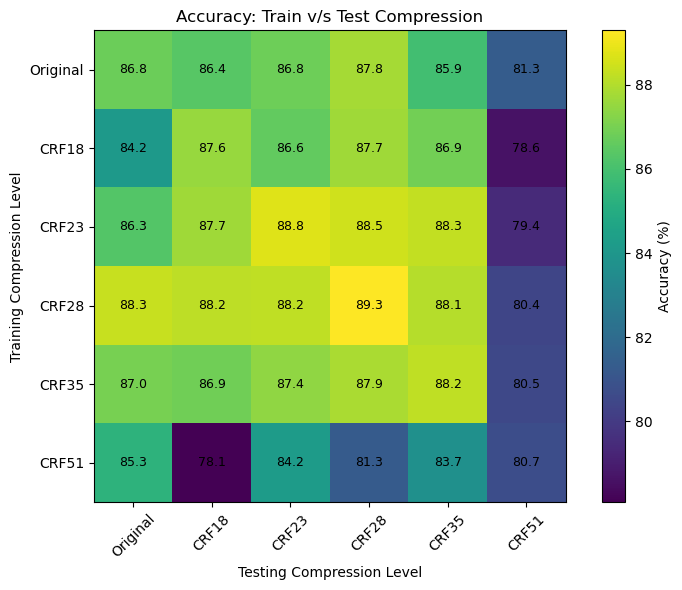

Saved: /export/fs06/ahallur1/cholec80/result_exports/heatmap_mean_video_precision.png


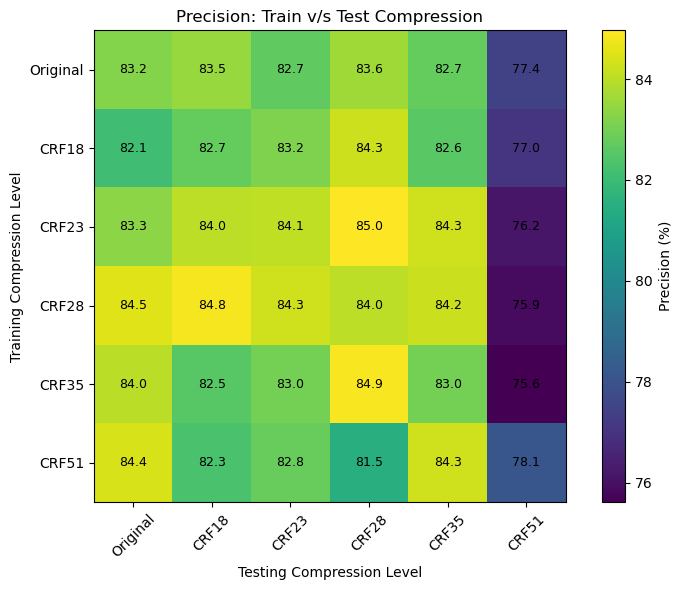

Saved: /export/fs06/ahallur1/cholec80/result_exports/heatmap_mean_video_recall.png


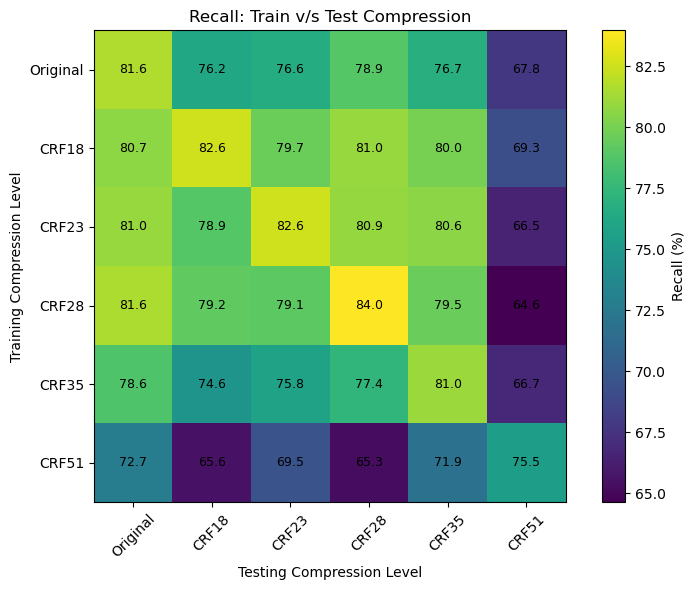

Saved: /export/fs06/ahallur1/cholec80/result_exports/heatmap_mean_video_f1.png


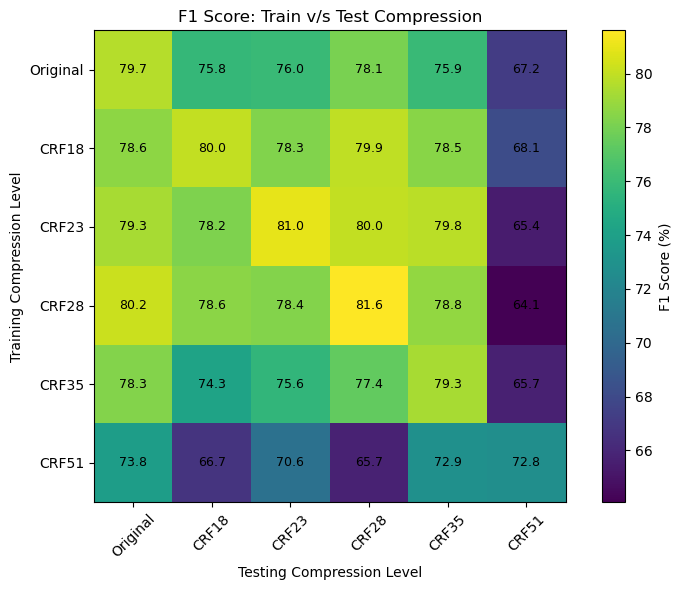

Saved: /export/fs06/ahallur1/cholec80/result_exports/heatmap_mean_video_jaccard.png


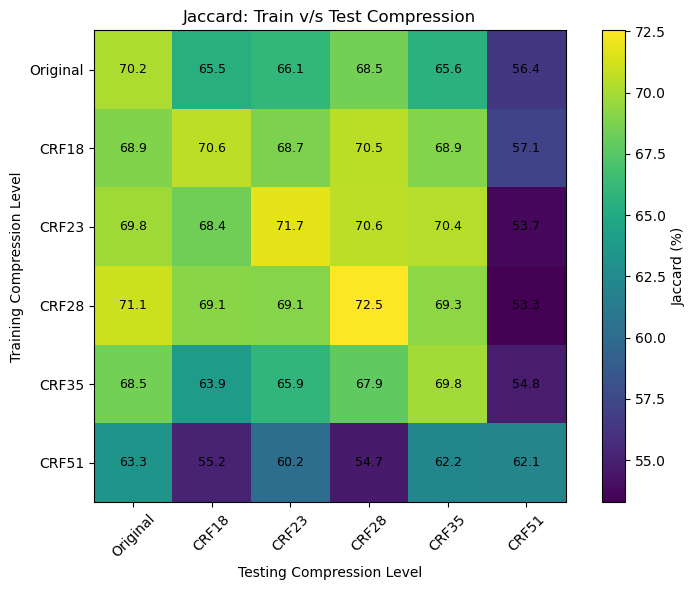

In [8]:
def save_fig(filename):
    path = RESULT_EXPORT_DIR / filename
    plt.savefig(path, bbox_inches="tight", dpi=220)
    print("Saved:", path)

metric_display = {
    "mean_video_accuracy": "Accuracy",
    "mean_video_precision": "Precision",
    "mean_video_recall": "Recall",
    "mean_video_f1": "F1 Score",
    "mean_video_jaccard": "Jaccard",
}

for metric, metric_label in metric_display.items():
    pivot = pair_summary_df.pivot(index="train_condition", columns="test_condition", values=metric).reindex(index=CONDITIONS, columns=CONDITIONS)
    plt.figure(figsize=(8, 6))
    im = plt.imshow(pivot.values * 100)
    plt.xticks(range(len(CONDITIONS)), CONDITIONS, rotation=45)
    plt.yticks(range(len(CONDITIONS)), CONDITIONS)
    plt.colorbar(im, label=f"{metric_label} (%)")
    for i in range(len(CONDITIONS)):
        for j in range(len(CONDITIONS)):
            val = pivot.iloc[i, j]
            if pd.notna(val):
                plt.text(j, i, f"{val*100:.1f}", ha="center", va="center", fontsize=9)
    plt.title(f"{metric_label}: Train v/s Test Compression")
    plt.xlabel("Testing Compression Level")
    plt.ylabel("Training Compression Level")
    plt.tight_layout()
    save_fig(f"heatmap_{metric}.png")
    plt.show()


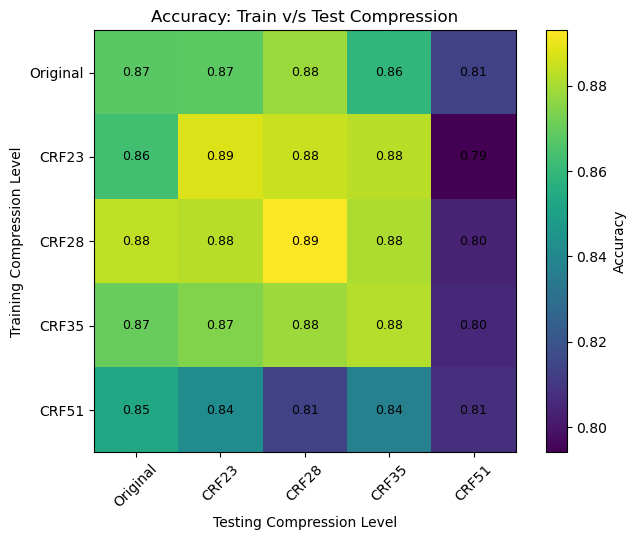

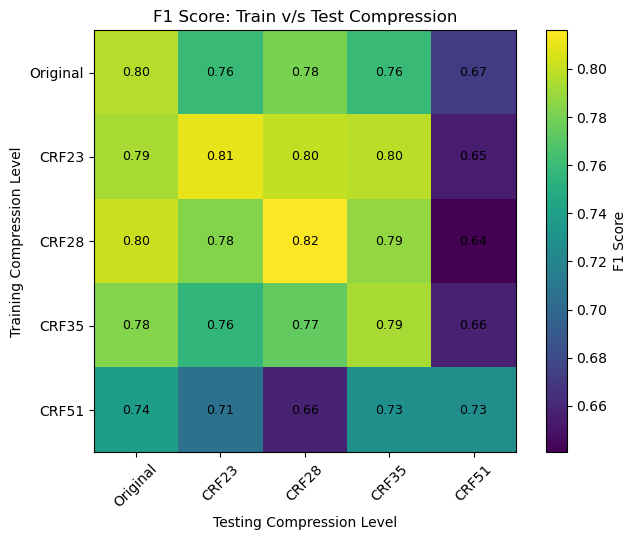

In [24]:
no_crf18_conditions = [cond for cond in CONDITIONS if cond != "CRF18"]
raw_metric_display = {
    "mean_video_accuracy": "Accuracy",
    "mean_video_f1": "F1 Score",
}

for metric, metric_label in raw_metric_display.items():
    pivot = pair_summary_df.pivot(index="train_condition", columns="test_condition", values=metric).reindex(index=no_crf18_conditions, columns=no_crf18_conditions)
    plt.figure(figsize=(7, 5.5))
    im = plt.imshow(pivot.values)
    plt.xticks(range(len(no_crf18_conditions)), no_crf18_conditions, rotation=45)
    plt.yticks(range(len(no_crf18_conditions)), no_crf18_conditions)
    plt.colorbar(im, label=metric_label)
    for i in range(len(no_crf18_conditions)):
        for j in range(len(no_crf18_conditions)):
            val = pivot.iloc[i, j]
            if pd.notna(val):
                plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)
    plt.title(f"{metric_label}: Train v/s Test Compression")
    plt.xlabel("Testing Compression Level")
    plt.ylabel("Training Compression Level")
    plt.tight_layout()
    plt.show()


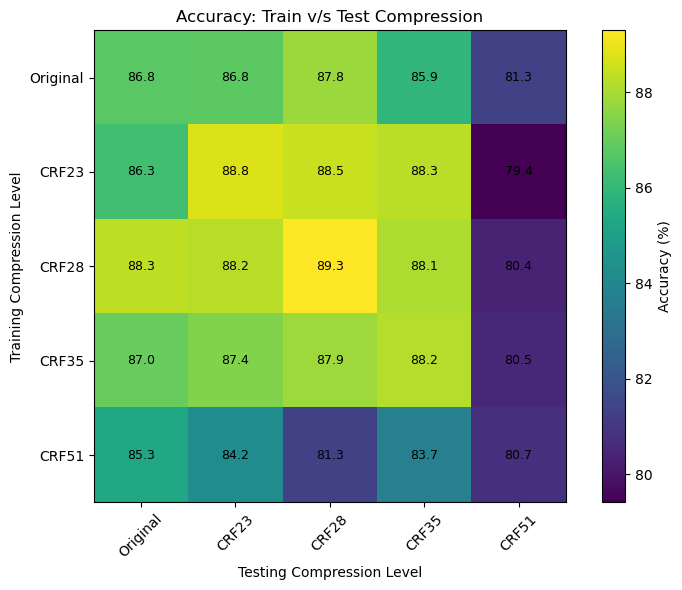

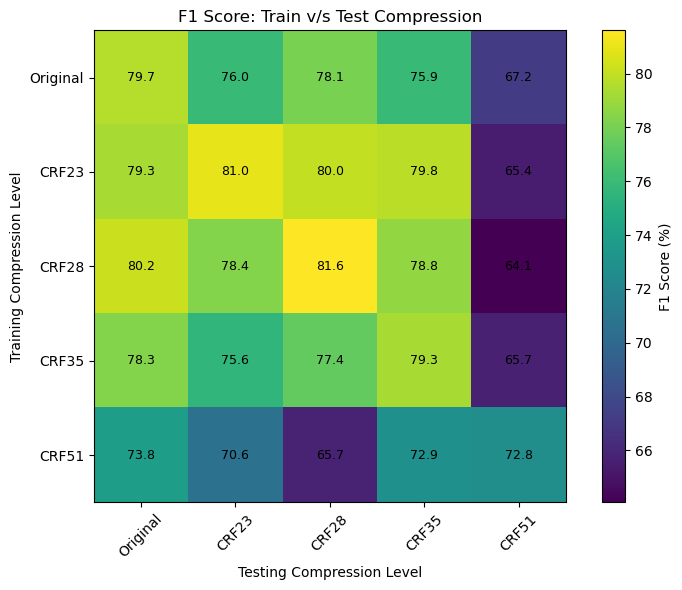

In [10]:
filtered_conditions = [cond for cond in CONDITIONS if cond != "CRF18"]
filtered_metric_display = {
    "mean_video_accuracy": "Accuracy",
    "mean_video_f1": "F1 Score",
}

for metric, metric_label in filtered_metric_display.items():
    pivot = (
        pair_summary_df
        .pivot(index="train_condition", columns="test_condition", values=metric)
        .reindex(index=filtered_conditions, columns=filtered_conditions)
    )
    plt.figure(figsize=(8, 6))
    im = plt.imshow(pivot.values * 100)
    plt.xticks(range(len(filtered_conditions)), filtered_conditions, rotation=45)
    plt.yticks(range(len(filtered_conditions)), filtered_conditions)
    plt.colorbar(im, label=f"{metric_label} (%)")
    for i in range(len(filtered_conditions)):
        for j in range(len(filtered_conditions)):
            val = pivot.iloc[i, j]
            if pd.notna(val):
                plt.text(j, i, f"{val*100:.1f}", ha="center", va="center", fontsize=9)
    plt.title(f"{metric_label}: Train v/s Test Compression")
    plt.xlabel("Testing Compression Level")
    plt.ylabel("Training Compression Level")
    plt.tight_layout()
    plt.show()


In [11]:
diag_rows = []
for cond in CONDITIONS:
    self_row = pair_summary_df[(pair_summary_df["train_condition"] == cond) & (pair_summary_df["test_condition"] == cond)]
    if self_row.empty:
        continue
    self_row = self_row.iloc[0]
    cross = pair_summary_df[(pair_summary_df["train_condition"] == cond) & (pair_summary_df["test_condition"] != cond)]
    diag_rows.append({
        "condition": cond,
        "self_accuracy": self_row["mean_video_accuracy"] * 100,
        "self_jaccard": self_row["mean_video_jaccard"] * 100,
        "mean_cross_accuracy": cross["mean_video_accuracy"].mean() * 100 if not cross.empty else np.nan,
        "mean_cross_jaccard": cross["mean_video_jaccard"].mean() * 100 if not cross.empty else np.nan,
    })
diag_df = pd.DataFrame(diag_rows)
diag_df["accuracy_drop"] = diag_df["self_accuracy"] - diag_df["mean_cross_accuracy"]
diag_df["jaccard_drop"] = diag_df["self_jaccard"] - diag_df["mean_cross_jaccard"]
diag_df

,condition,self_accuracy,self_jaccard,mean_cross_accuracy,mean_cross_jaccard,accuracy_drop,jaccard_drop
0,Original,86.758600,70.205309,85.641867,64.400603,1.116734,5.804706
1,CRF18,87.554816,70.603896,84.795665,66.857336,2.759151,3.746560
2,CRF23,88.757682,71.716912,86.032591,66.564403,2.725091,5.152509
3,CRF28,89.297202,72.539641,86.648269,66.361070,2.648934,6.178571
4,CRF35,88.201457,69.849869,85.934305,64.196035,2.267152,5.653834
5,CRF51,80.732965,62.074639,82.524283,59.097012,-1.791318,2.977627


Saved: /export/fs06/ahallur1/cholec80/result_exports/bar_self_accuracy.png


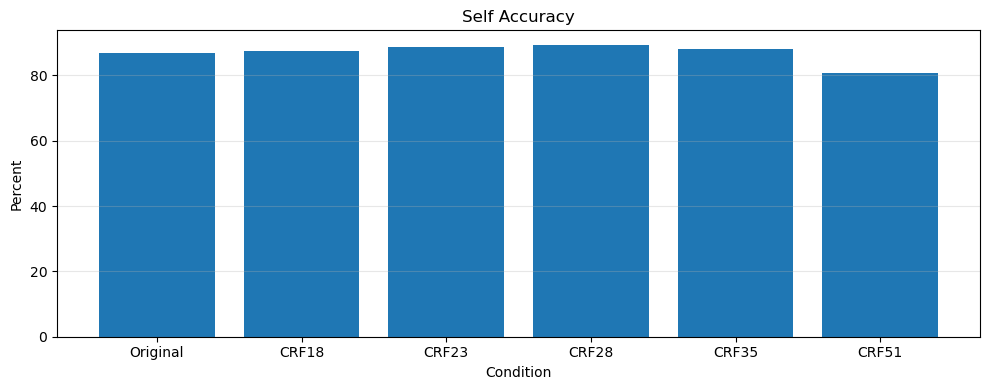

Saved: /export/fs06/ahallur1/cholec80/result_exports/bar_mean_cross_accuracy.png


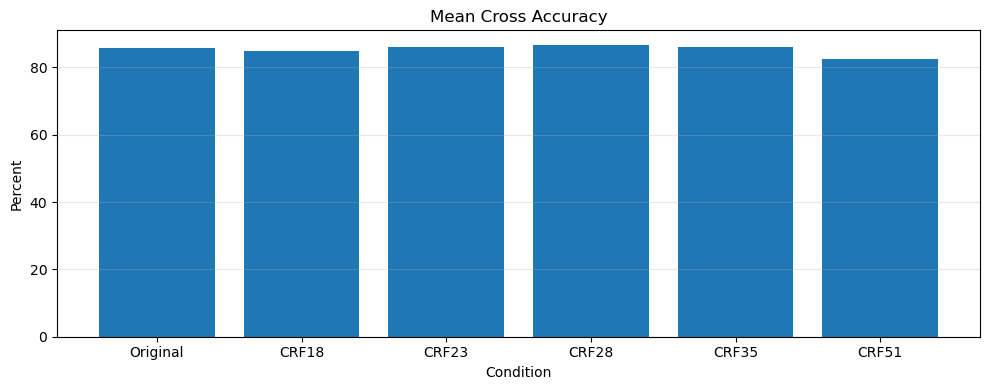

Saved: /export/fs06/ahallur1/cholec80/result_exports/bar_accuracy_drop.png


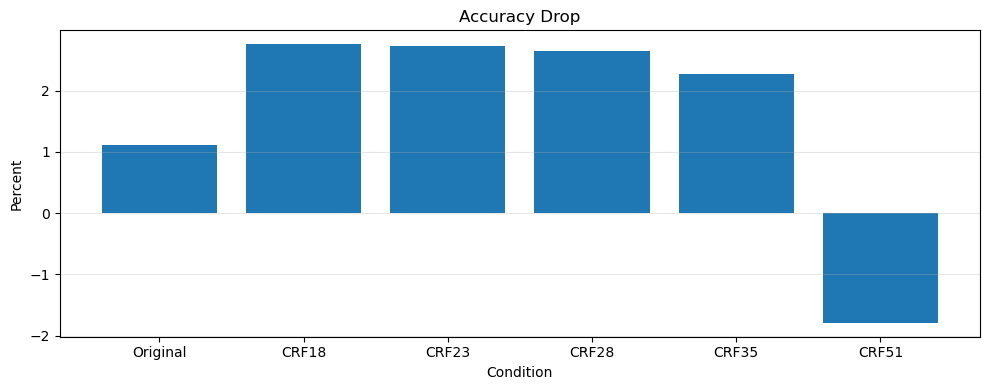

Saved: /export/fs06/ahallur1/cholec80/result_exports/bar_self_jaccard.png


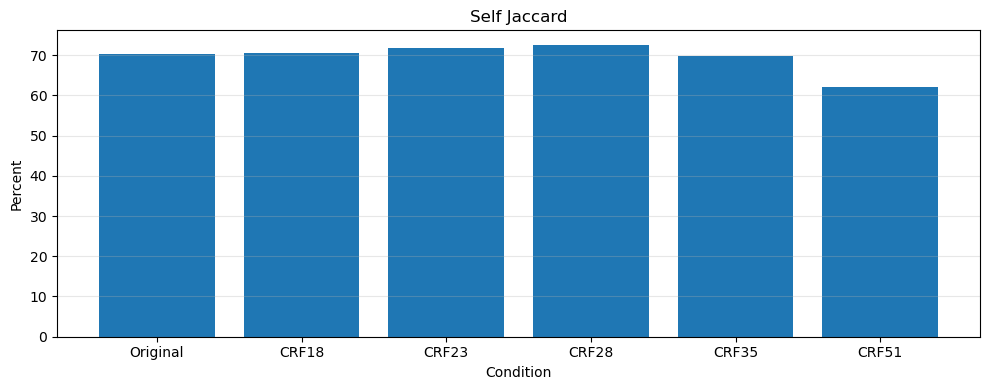

Saved: /export/fs06/ahallur1/cholec80/result_exports/bar_mean_cross_jaccard.png


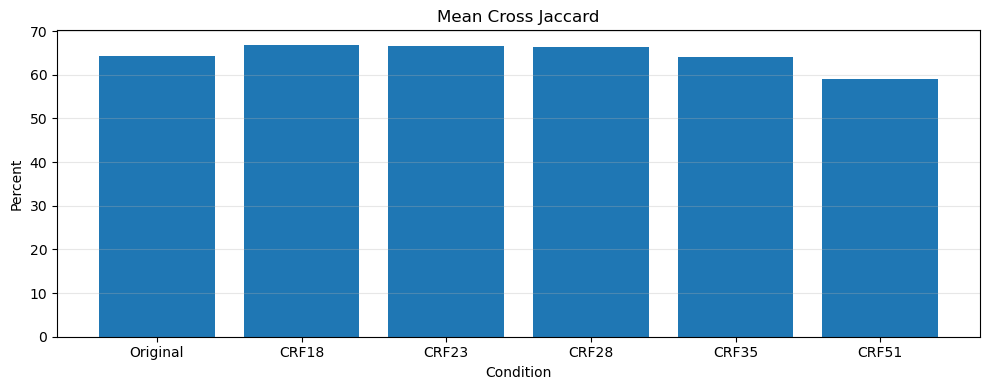

Saved: /export/fs06/ahallur1/cholec80/result_exports/bar_jaccard_drop.png


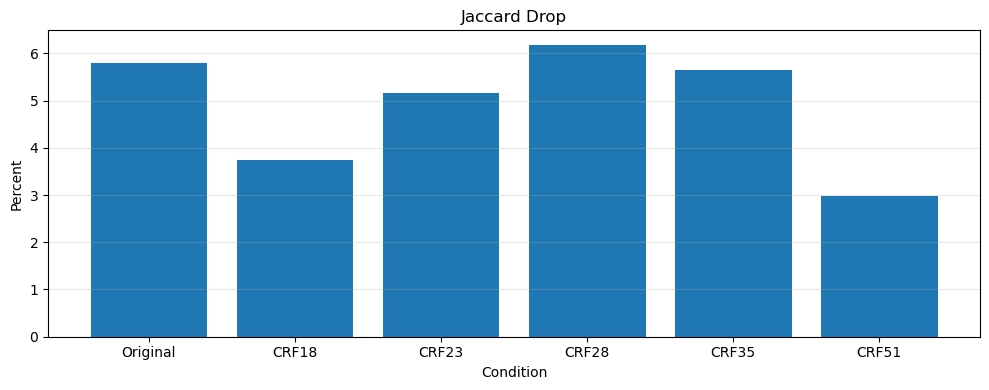

In [12]:
for metric in ["self_accuracy", "mean_cross_accuracy", "accuracy_drop", "self_jaccard", "mean_cross_jaccard", "jaccard_drop"]:
    plt.figure(figsize=(10, 4))
    plt.bar(diag_df["condition"], diag_df[metric])
    plt.title(metric.replace("_", " ").title())
    plt.ylabel("Percent")
    plt.xlabel("Condition")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    save_fig(f"bar_{metric}.png")
    plt.show()

Saved: /export/fs06/ahallur1/cholec80/result_exports/heatmap_delta_mean_video_accuracy.png


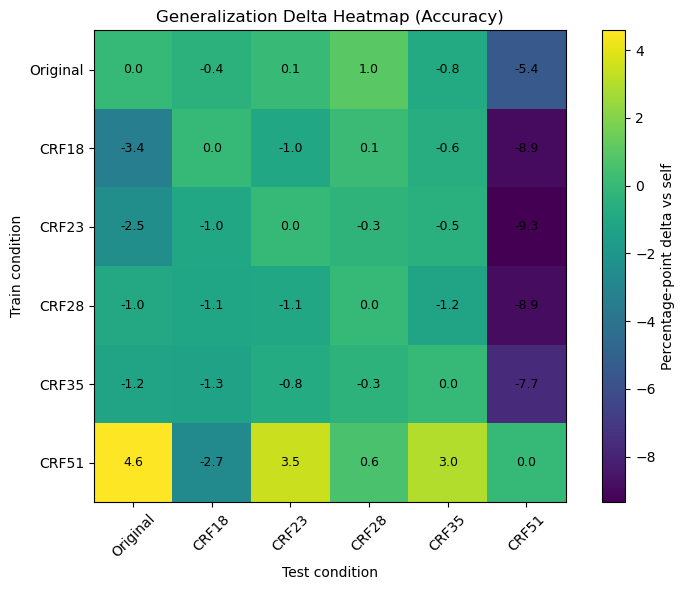

Saved: /export/fs06/ahallur1/cholec80/result_exports/heatmap_delta_mean_video_jaccard.png


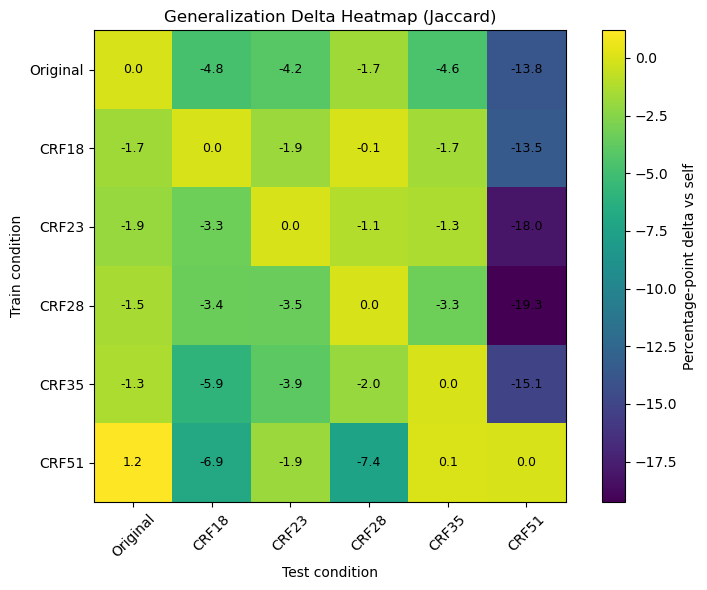

In [13]:
for metric in ["mean_video_accuracy", "mean_video_jaccard"]:
    pivot = pair_summary_df.pivot(index="train_condition", columns="test_condition", values=metric).reindex(index=CONDITIONS, columns=CONDITIONS)
    delta = pivot.copy()
    for cond in CONDITIONS:
        self_val = pivot.loc[cond, cond]
        if pd.notna(self_val):
            delta.loc[cond, :] = (pivot.loc[cond, :] - self_val) * 100
        else:
            delta.loc[cond, :] = np.nan

    plt.figure(figsize=(8, 6))
    im = plt.imshow(delta.values)
    plt.xticks(range(len(CONDITIONS)), CONDITIONS, rotation=45)
    plt.yticks(range(len(CONDITIONS)), CONDITIONS)
    plt.colorbar(im, label="Percentage-point delta vs self")
    for i in range(len(CONDITIONS)):
        for j in range(len(CONDITIONS)):
            val = delta.iloc[i, j]
            if pd.notna(val):
                plt.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=9)
    plt.title(f"Generalization Delta Heatmap ({metric.replace('mean_video_', '').title()})")
    plt.xlabel("Test condition")
    plt.ylabel("Train condition")
    plt.tight_layout()
    save_fig(f"heatmap_delta_{metric}.png")
    plt.show()

In [14]:
phase_grid_rows = []
for _, row in pair_summary_df.iterrows():
    for phase in PHASES:
        phase_grid_rows.append({
            "train_condition": row["train_condition"],
            "test_condition": row["test_condition"],
            "phase": phase,
            "precision": row[f"phase_prec_{phase}"] * 100,
            "recall": row[f"phase_rec_{phase}"] * 100,
            "f1": row[f"phase_f1_{phase}"] * 100,
            "jaccard": row[f"phase_jac_{phase}"] * 100,
        })

phase_grid_df = pd.DataFrame(phase_grid_rows)
phase_grid_df.head()


,train_condition,test_condition,phase,precision,recall,f1,jaccard
0,Original,Original,Preparation,97.887865,71.440583,82.598833,70.356059
1,Original,Original,CalotTriangleDissection,94.465337,82.230011,87.924055,78.450424
2,Original,Original,ClippingCutting,70.122760,77.559633,73.653947,58.295408
3,Original,Original,GallbladderDissection,83.370244,92.747023,87.809016,78.267444
4,Original,Original,GallbladderPackaging,73.778018,90.583554,81.321625,68.522699


Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_Preparation_precision_heatmap.png


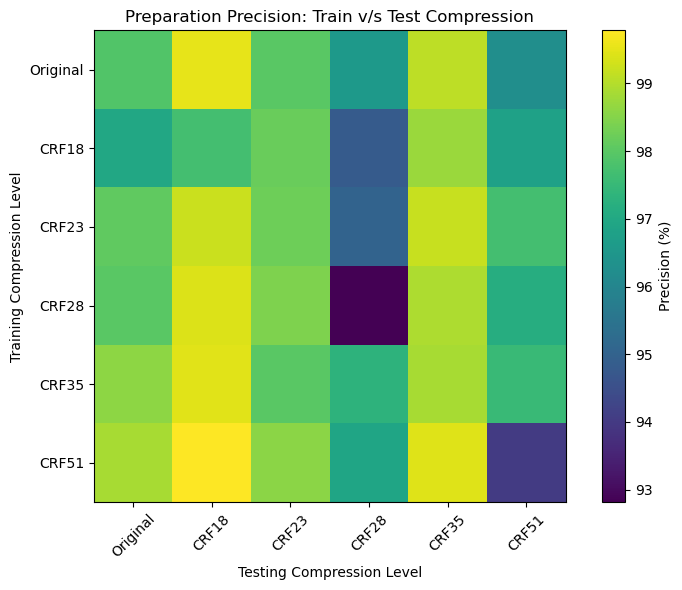

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_Preparation_recall_heatmap.png


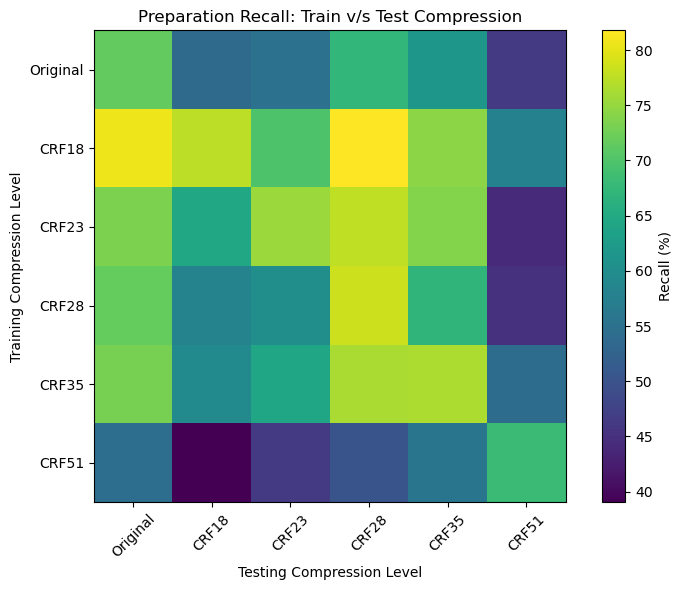

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_Preparation_f1_heatmap.png


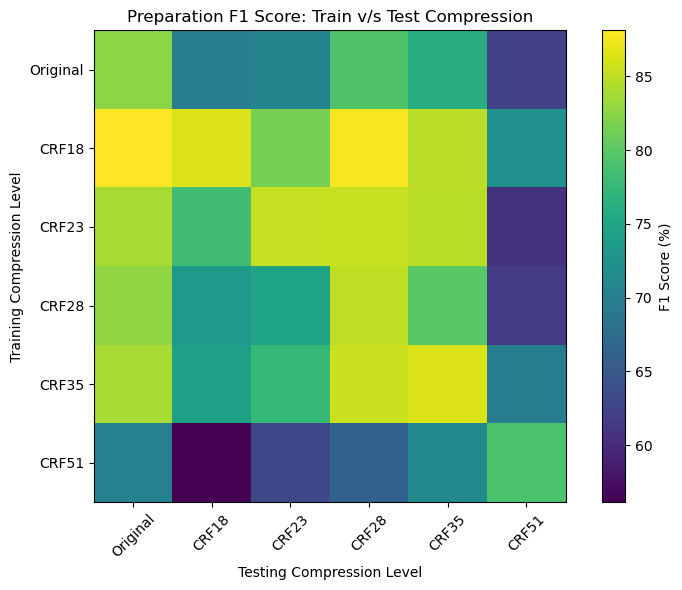

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_Preparation_jaccard_heatmap.png


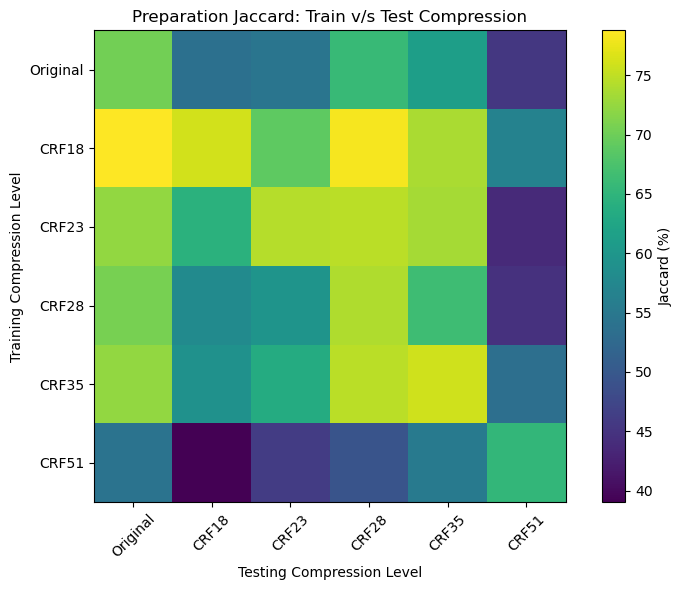

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_CalotTriangleDissection_precision_heatmap.png


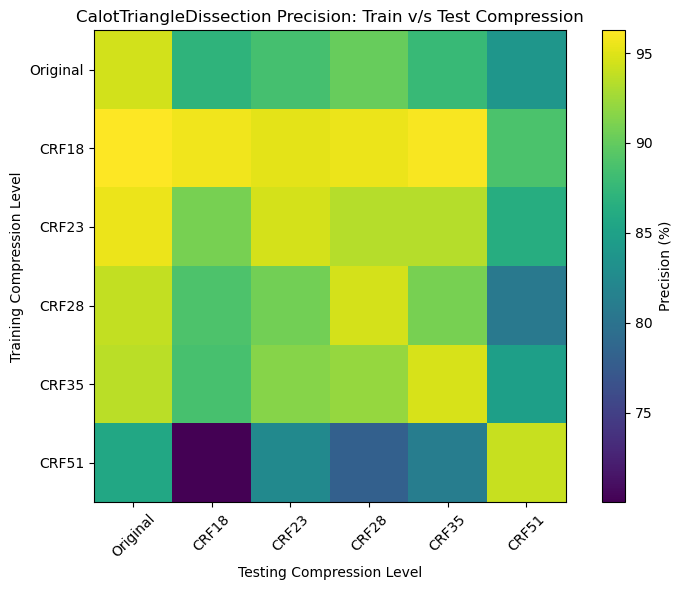

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_CalotTriangleDissection_recall_heatmap.png


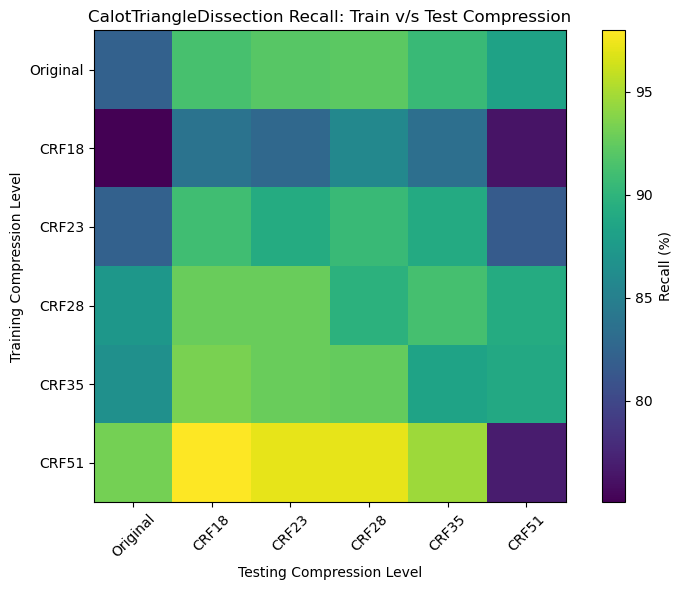

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_CalotTriangleDissection_f1_heatmap.png


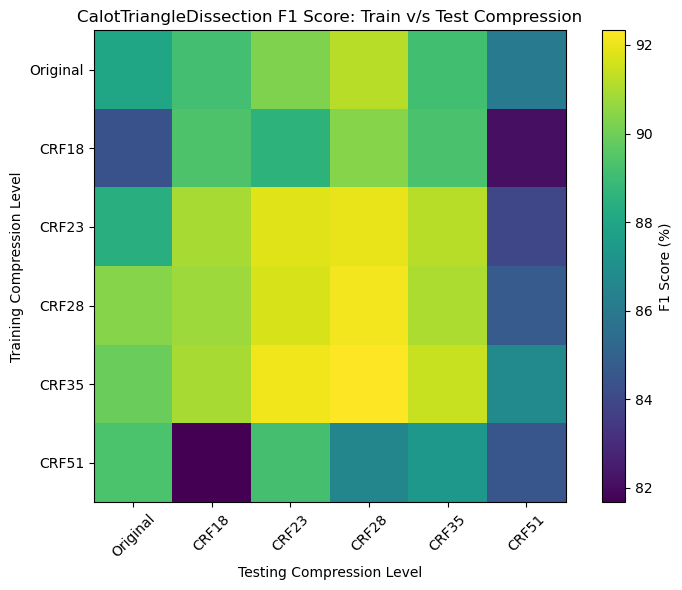

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_CalotTriangleDissection_jaccard_heatmap.png


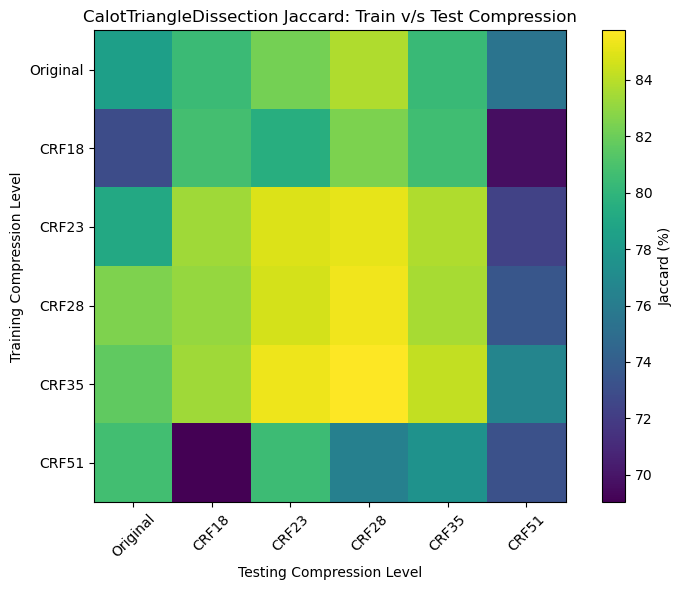

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_ClippingCutting_precision_heatmap.png


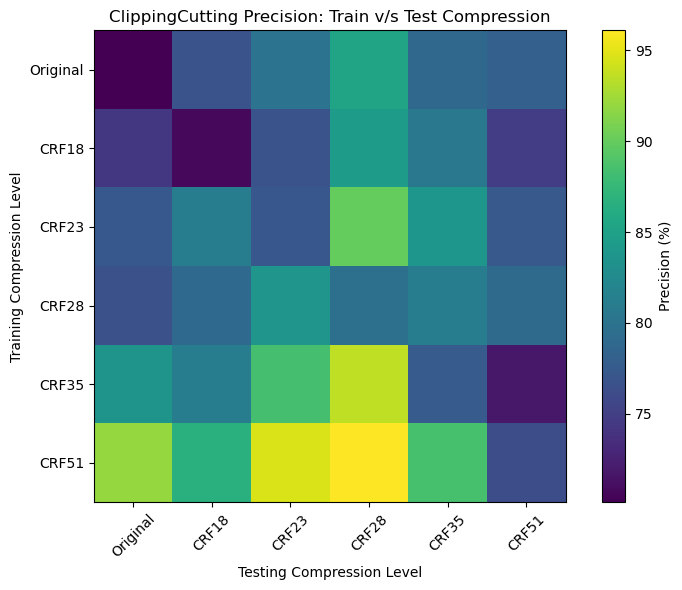

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_ClippingCutting_recall_heatmap.png


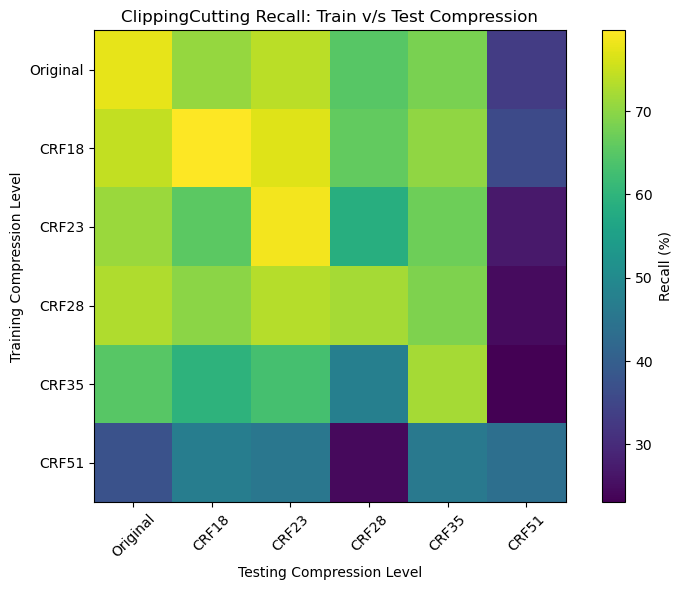

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_ClippingCutting_f1_heatmap.png


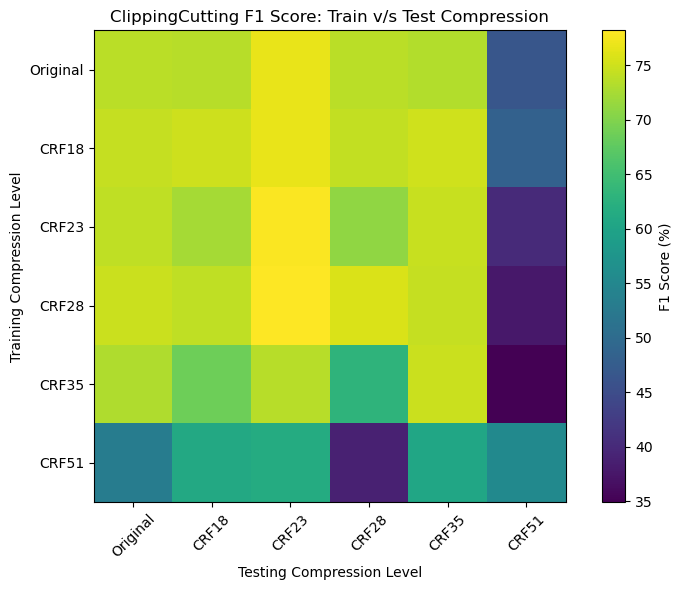

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_ClippingCutting_jaccard_heatmap.png


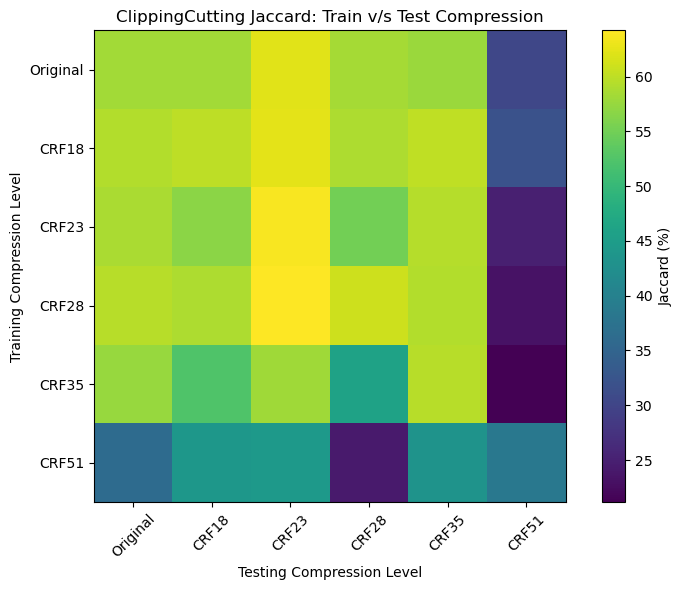

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_GallbladderDissection_precision_heatmap.png


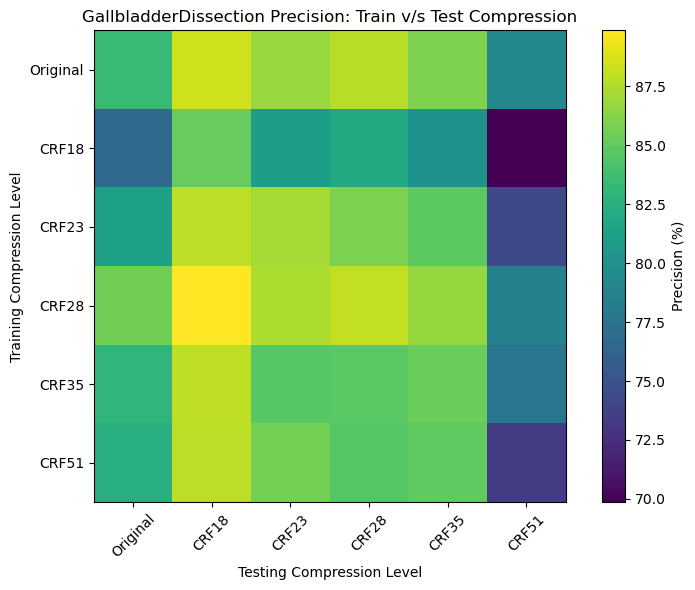

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_GallbladderDissection_recall_heatmap.png


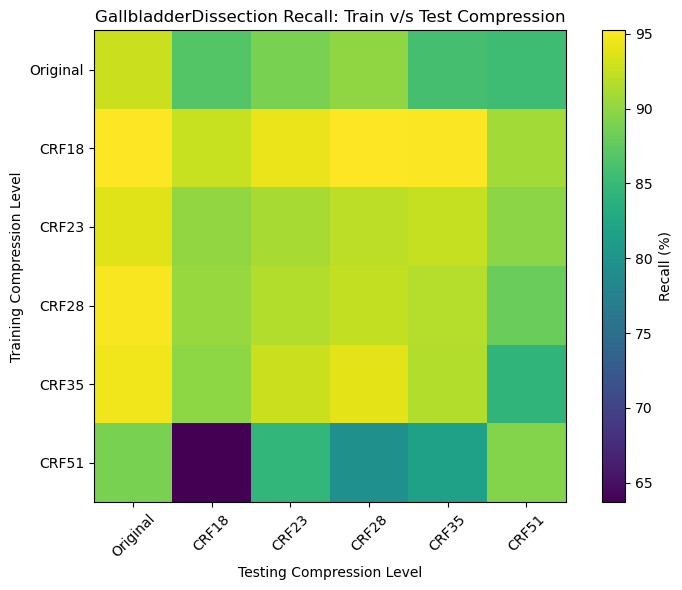

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_GallbladderDissection_f1_heatmap.png


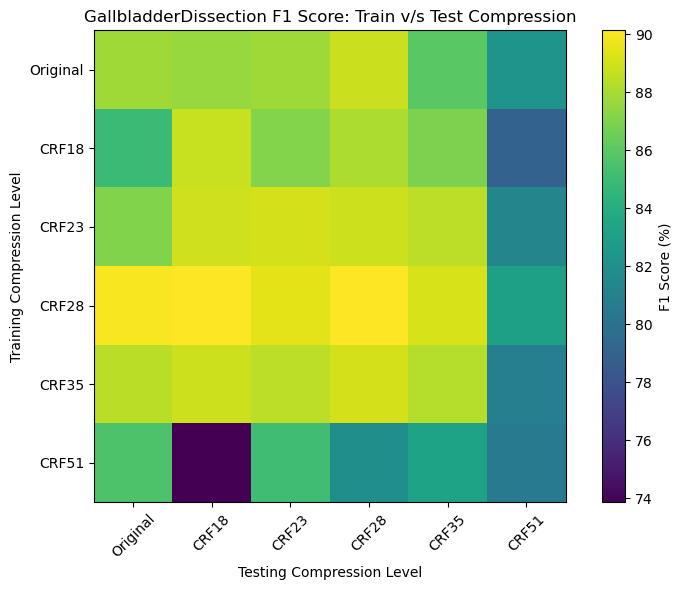

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_GallbladderDissection_jaccard_heatmap.png


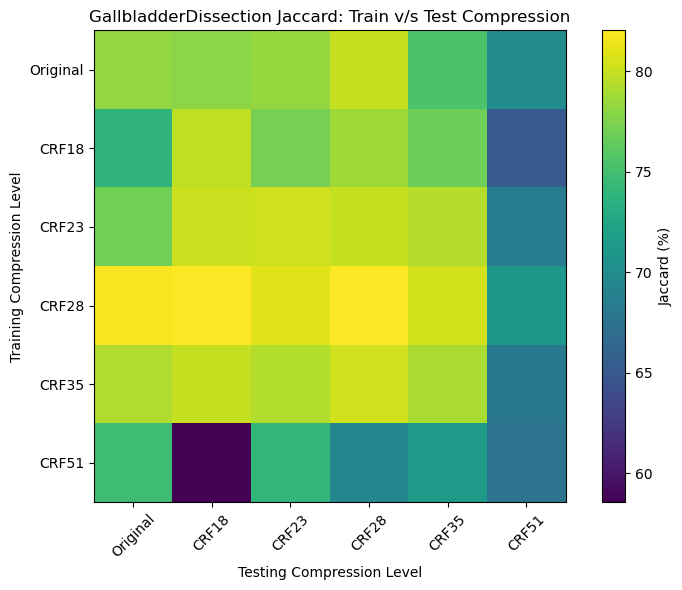

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_GallbladderPackaging_precision_heatmap.png


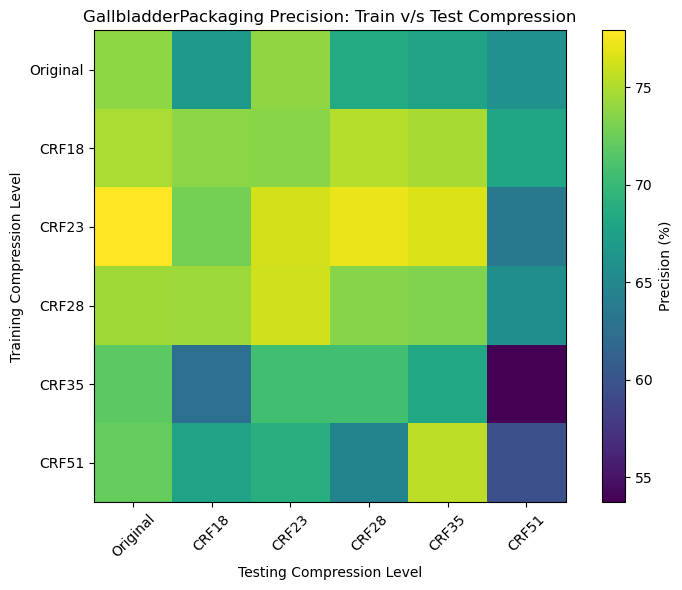

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_GallbladderPackaging_recall_heatmap.png


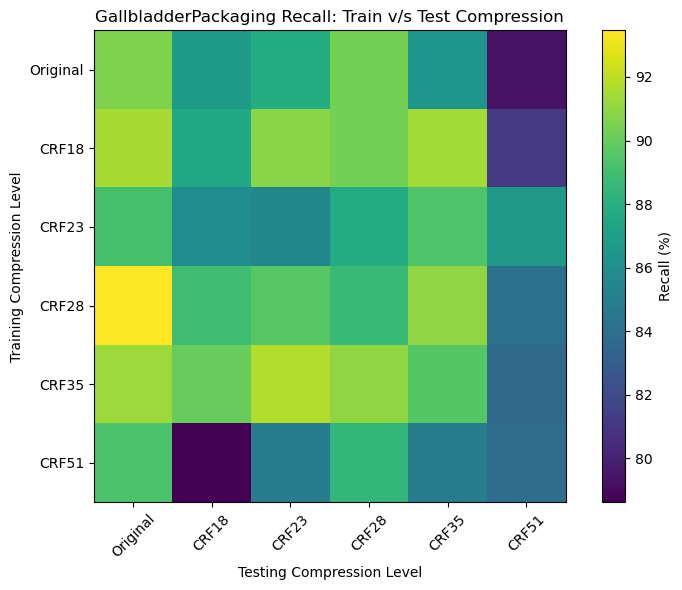

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_GallbladderPackaging_f1_heatmap.png


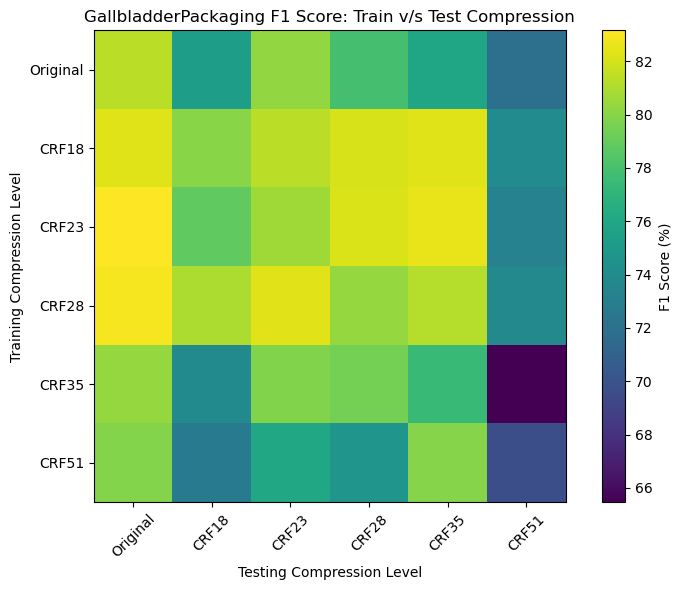

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_GallbladderPackaging_jaccard_heatmap.png


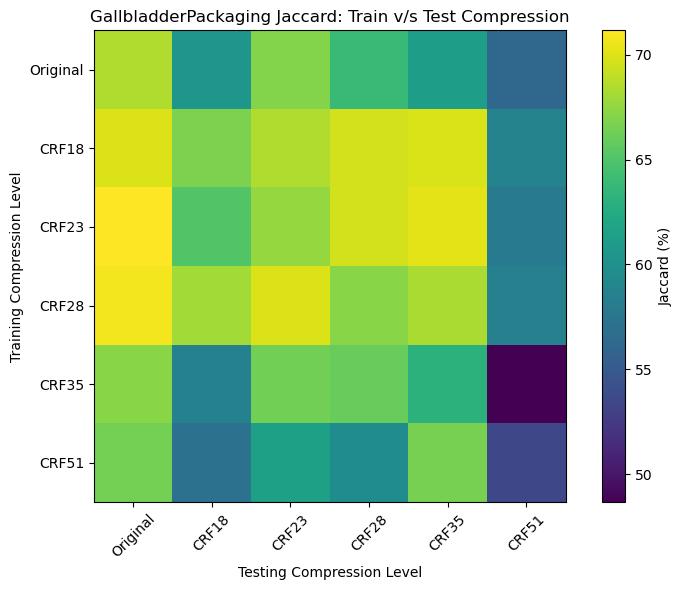

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_CleaningCoagulation_precision_heatmap.png


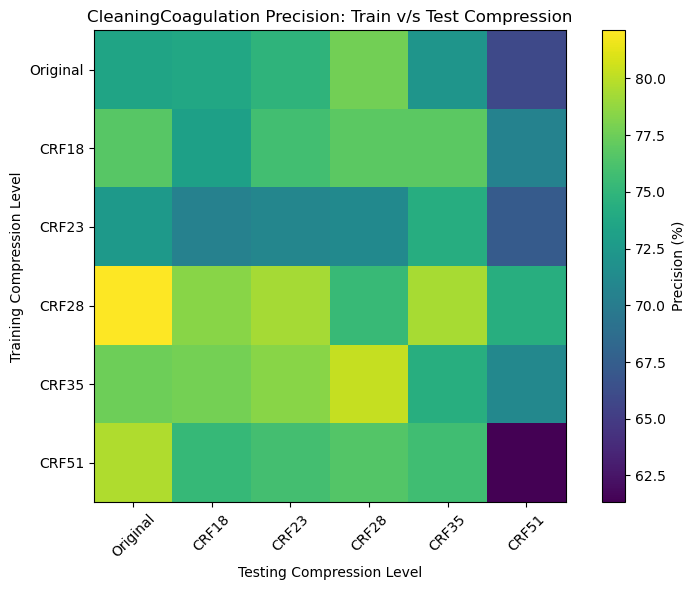

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_CleaningCoagulation_recall_heatmap.png


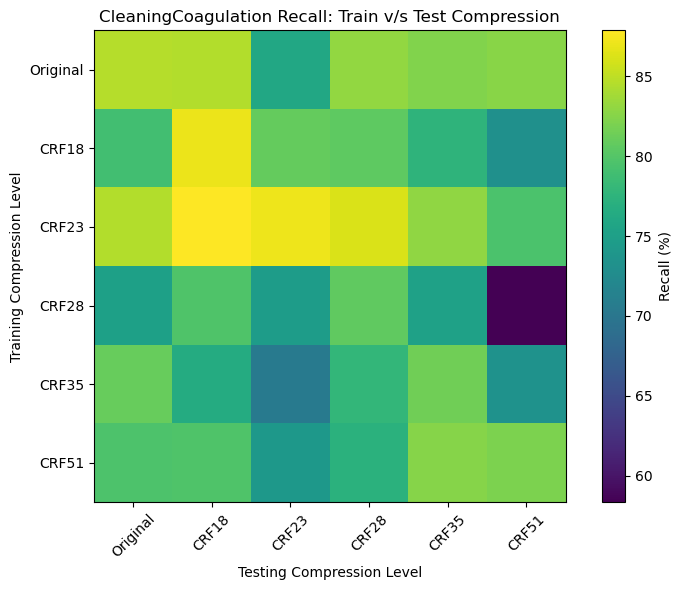

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_CleaningCoagulation_f1_heatmap.png


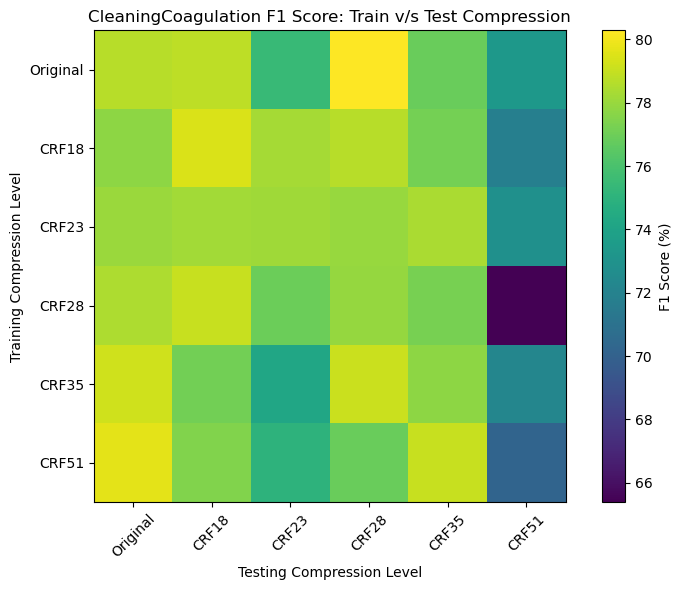

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_CleaningCoagulation_jaccard_heatmap.png


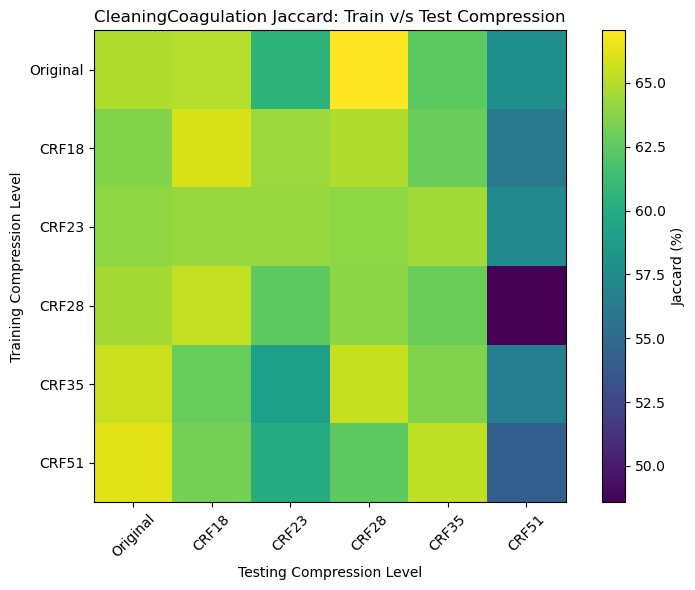

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_GallbladderRetraction_precision_heatmap.png


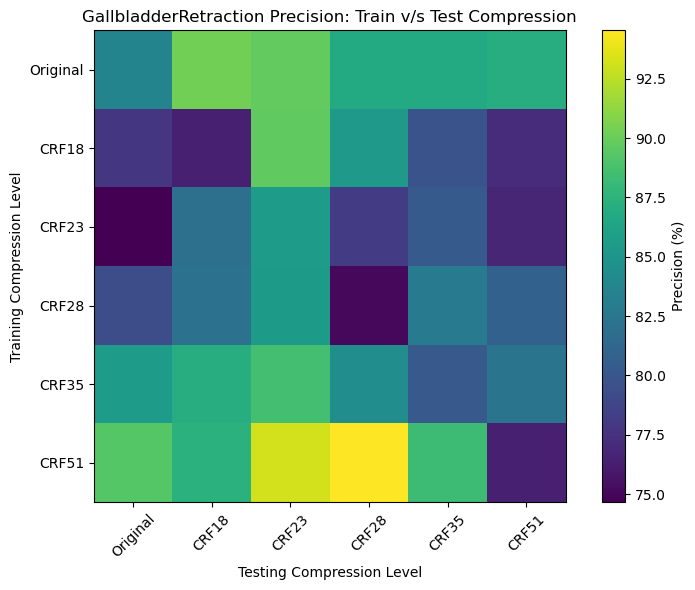

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_GallbladderRetraction_recall_heatmap.png


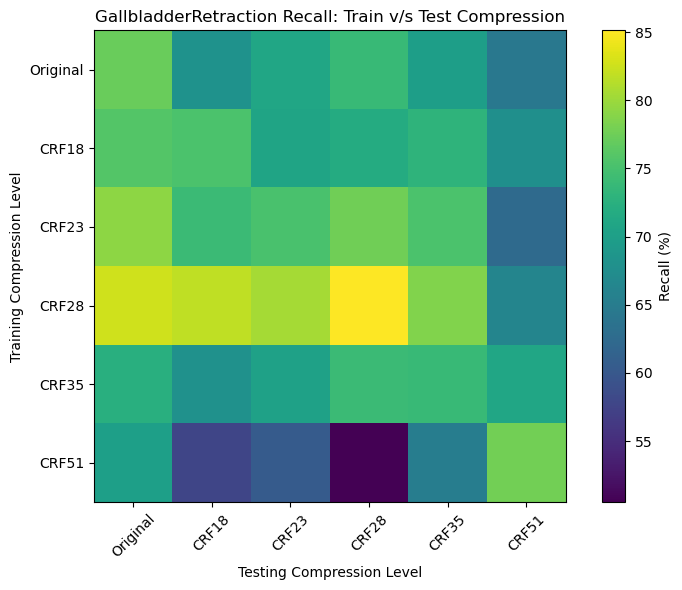

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_GallbladderRetraction_f1_heatmap.png


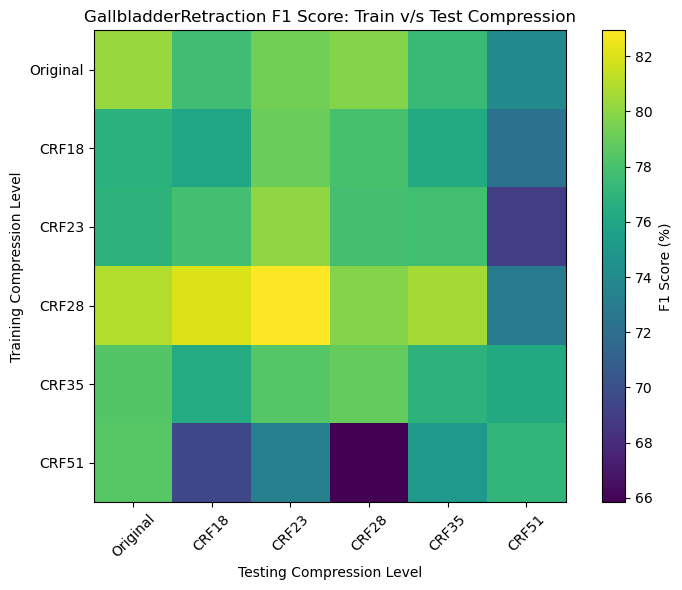

Saved: /export/fs06/ahallur1/cholec80/result_exports/phase_GallbladderRetraction_jaccard_heatmap.png


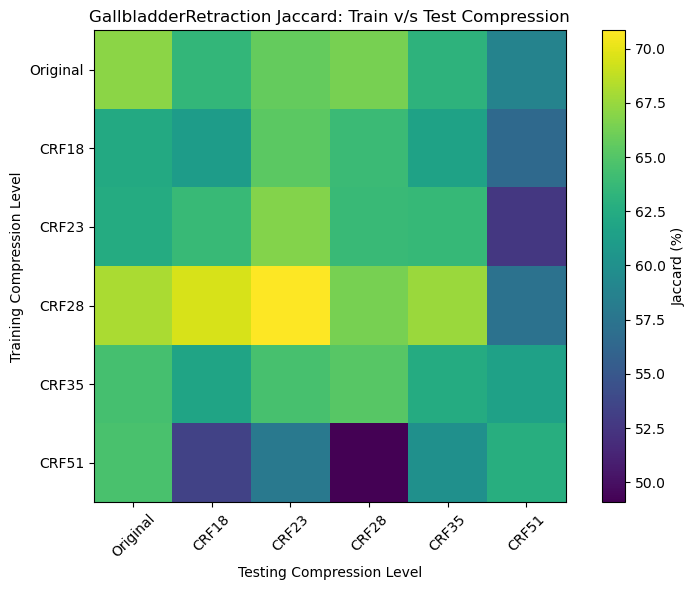

In [15]:
phase_metric_display = {
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1 Score",
    "jaccard": "Jaccard",
}

for phase in PHASES:
    subset = phase_grid_df[phase_grid_df["phase"] == phase]
    for metric, metric_label in phase_metric_display.items():
        pivot = subset.pivot(index="train_condition", columns="test_condition", values=metric).reindex(index=CONDITIONS, columns=CONDITIONS)

        plt.figure(figsize=(8, 6))
        im = plt.imshow(pivot.values)
        plt.xticks(range(len(CONDITIONS)), CONDITIONS, rotation=45)
        plt.yticks(range(len(CONDITIONS)), CONDITIONS)
        plt.colorbar(im, label=f"{metric_label} (%)")
        plt.title(f"{phase} {metric_label}: Train v/s Test Compression")
        plt.xlabel("Testing Compression Level")
        plt.ylabel("Training Compression Level")
        plt.tight_layout()
        save_fig(f"phase_{phase.replace(' ', '_')}_{metric}_heatmap.png")
        plt.show()


Saved: /export/fs06/ahallur1/cholec80/result_exports/curve_mean_video_accuracy.png


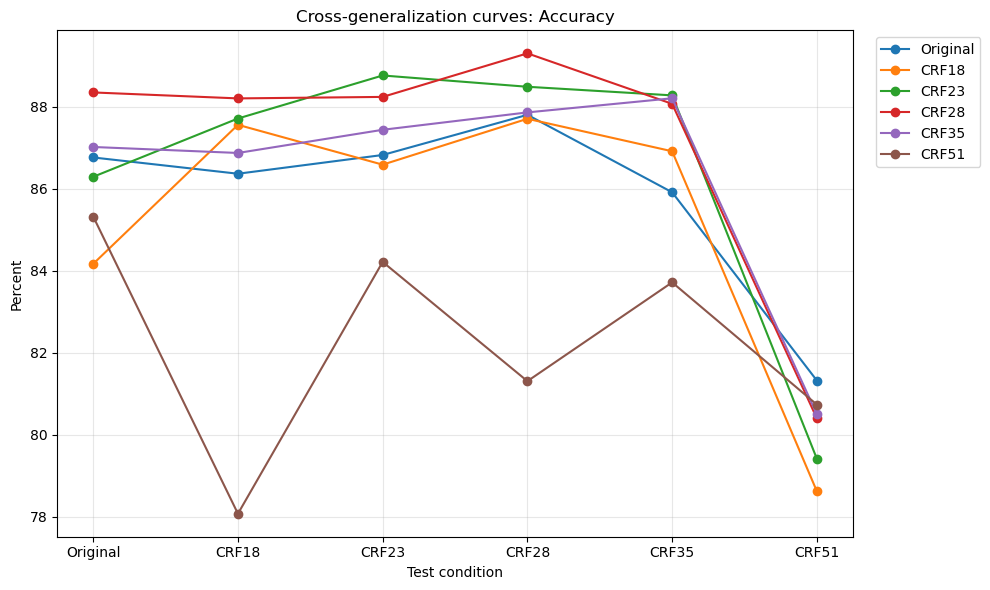

Saved: /export/fs06/ahallur1/cholec80/result_exports/curve_mean_video_jaccard.png


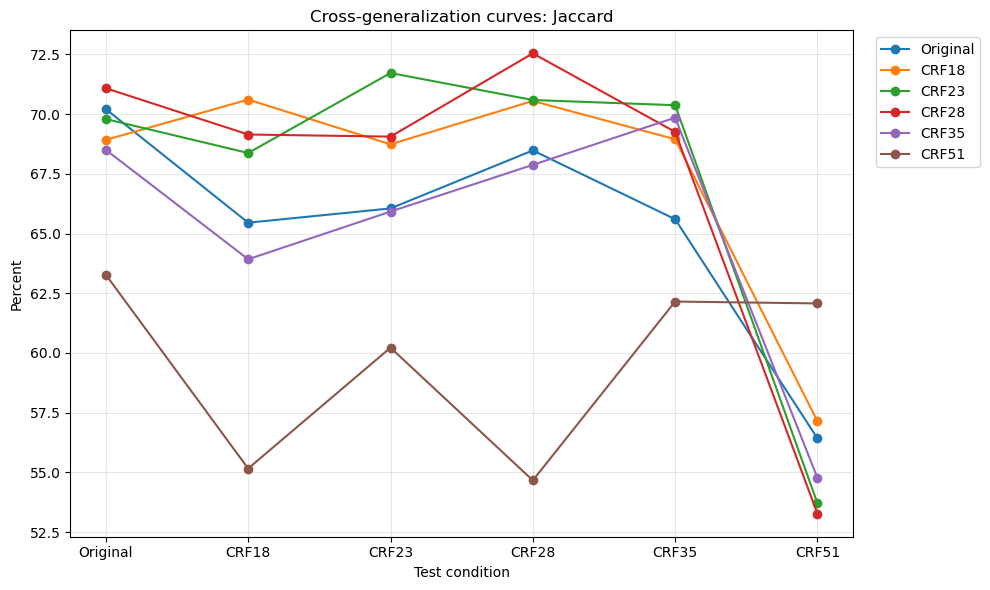

In [16]:
condition_order_numeric = {"Original": -1, "CRF18": 18, "CRF23": 23, "CRF28": 28, "CRF35": 35, "CRF51": 51}

for metric in ["mean_video_accuracy", "mean_video_jaccard"]:
    plt.figure(figsize=(10, 6))
    for train_cond in CONDITIONS:
        subset = pair_summary_df[pair_summary_df["train_condition"] == train_cond].copy()
        if subset.empty:
            continue
        subset["order"] = subset["test_condition"].map(condition_order_numeric)
        subset = subset.sort_values("order")
        plt.plot(subset["test_condition"], subset[metric] * 100, marker="o", label=train_cond)
    plt.title(f"Cross-generalization curves: {metric.replace('mean_video_', '').title()}")
    plt.xlabel("Test condition")
    plt.ylabel("Percent")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_fig(f"curve_{metric}.png")
    plt.show()

In [17]:
robustness_rows = []
for train_cond in CONDITIONS:
    subset = pair_summary_df[pair_summary_df["train_condition"] == train_cond]
    if subset.empty:
        continue
    robustness_rows.append({
        "train_condition": train_cond,
        "mean_accuracy_across_all_tests": subset["mean_video_accuracy"].mean() * 100,
        "worst_case_accuracy": subset["mean_video_accuracy"].min() * 100,
        "mean_jaccard_across_all_tests": subset["mean_video_jaccard"].mean() * 100,
        "worst_case_jaccard": subset["mean_video_jaccard"].min() * 100,
    })
robustness_df = pd.DataFrame(robustness_rows).sort_values("mean_jaccard_across_all_tests", ascending=False)
robustness_df

,train_condition,mean_accuracy_across_all_tests,worst_case_accuracy,mean_jaccard_across_all_tests,worst_case_jaccard
1,CRF18,85.255523,78.619293,67.481762,57.140763
2,CRF23,86.486773,79.412301,67.423155,53.705293
3,CRF28,87.089758,80.396664,67.390832,53.274545
0,Original,85.827989,81.319749,65.368054,56.424475
4,CRF35,86.312163,80.497986,65.138340,54.766234
5,CRF51,82.225730,78.072711,59.593283,54.668840


Saved: /export/fs06/ahallur1/cholec80/result_exports/robustness_mean_accuracy_across_all_tests.png


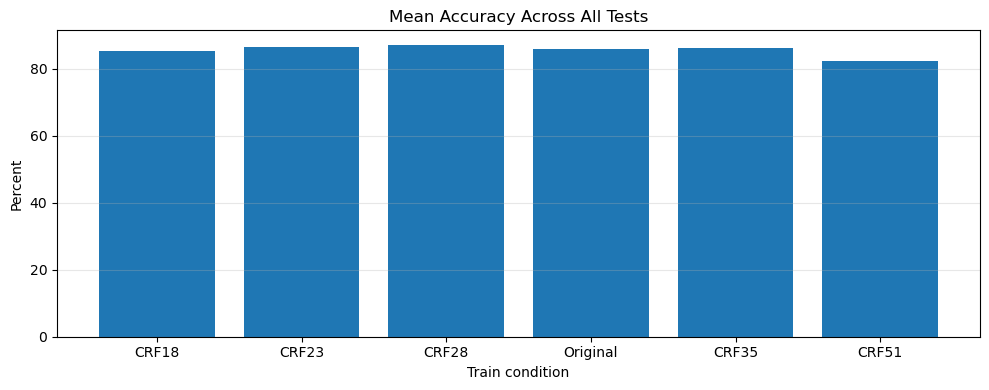

Saved: /export/fs06/ahallur1/cholec80/result_exports/robustness_worst_case_accuracy.png


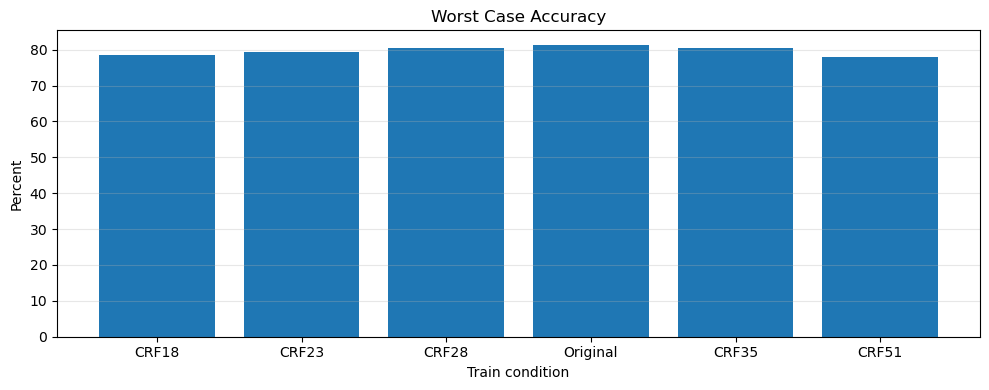

Saved: /export/fs06/ahallur1/cholec80/result_exports/robustness_mean_jaccard_across_all_tests.png


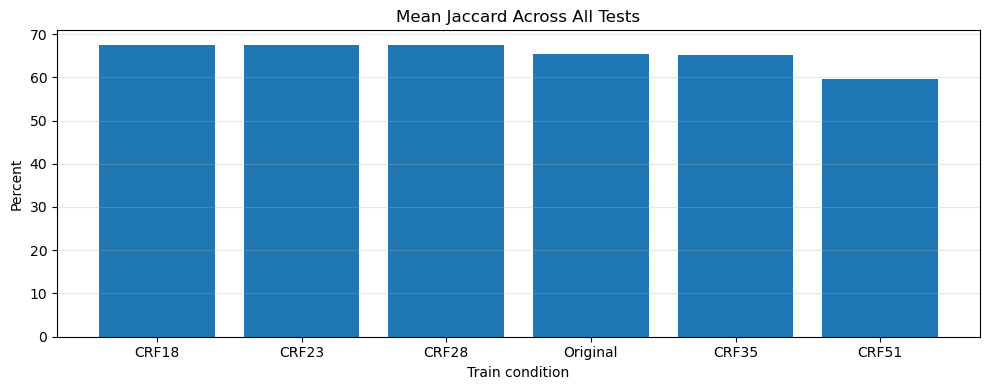

Saved: /export/fs06/ahallur1/cholec80/result_exports/robustness_worst_case_jaccard.png


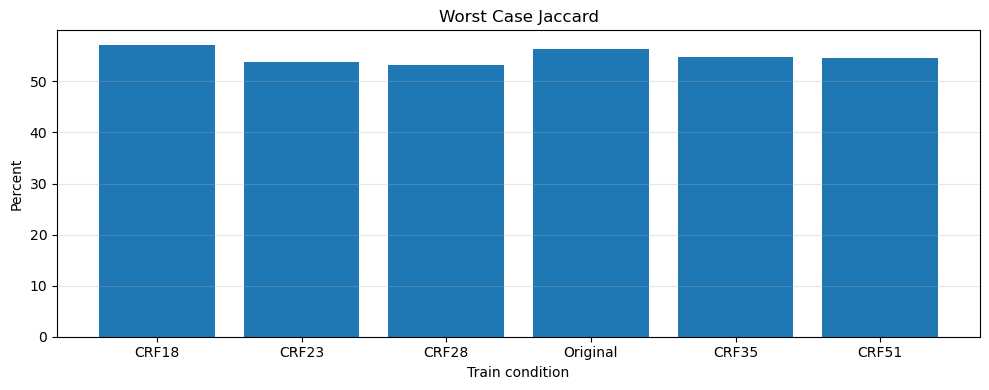

In [18]:
for metric in ["mean_accuracy_across_all_tests", "worst_case_accuracy", "mean_jaccard_across_all_tests", "worst_case_jaccard"]:
    plt.figure(figsize=(10, 4))
    plt.bar(robustness_df["train_condition"], robustness_df[metric])
    plt.title(metric.replace("_", " ").title())
    plt.ylabel("Percent")
    plt.xlabel("Train condition")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    save_fig(f"robustness_{metric}.png")
    plt.show()

Saved: /export/fs06/ahallur1/cholec80/result_exports/per_video_heatmap_train_Original.png


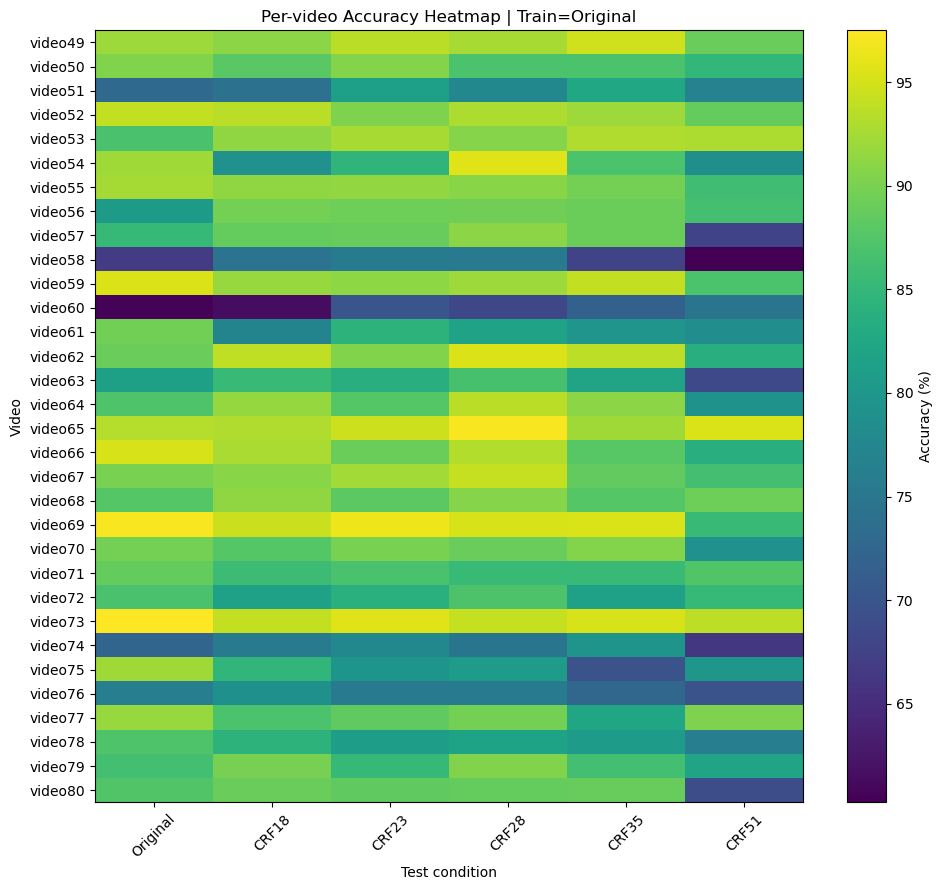

Saved: /export/fs06/ahallur1/cholec80/result_exports/per_video_heatmap_train_CRF18.png


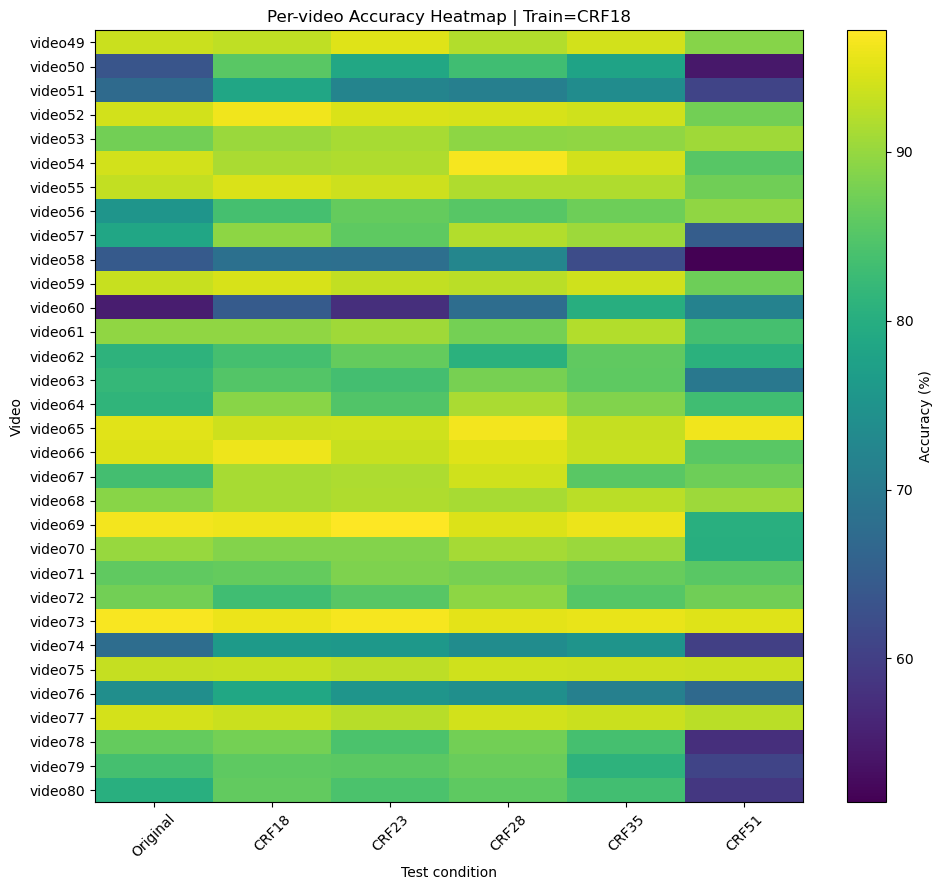

Saved: /export/fs06/ahallur1/cholec80/result_exports/per_video_heatmap_train_CRF23.png


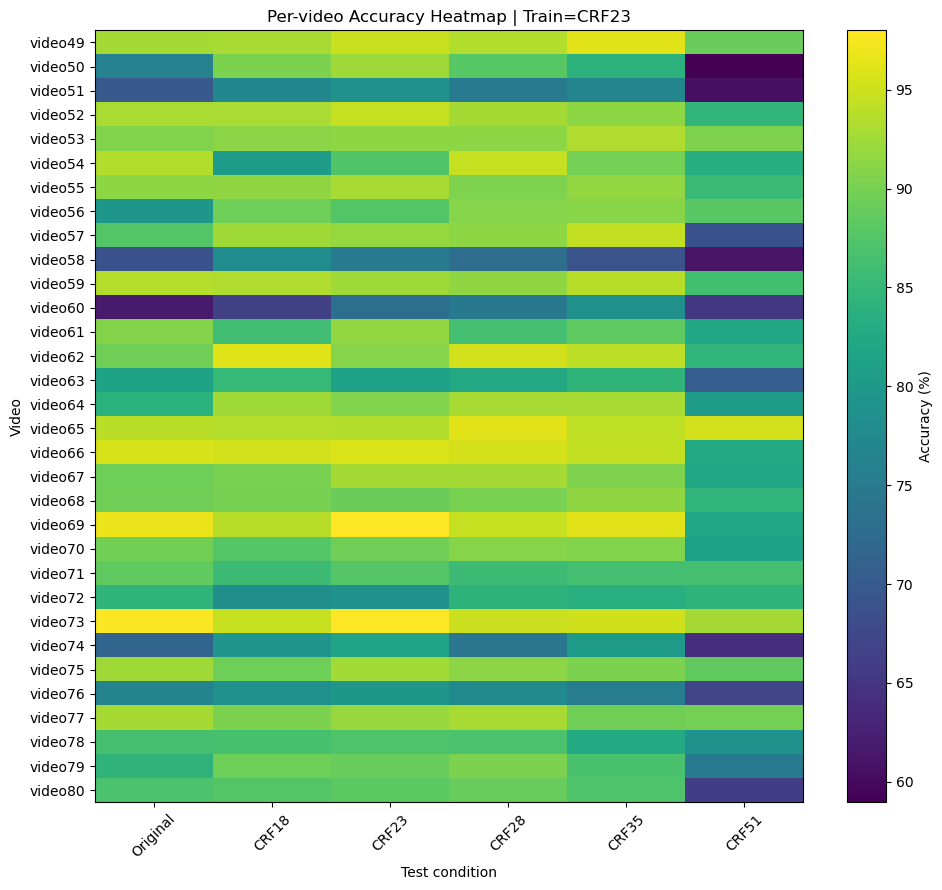

Saved: /export/fs06/ahallur1/cholec80/result_exports/per_video_heatmap_train_CRF28.png


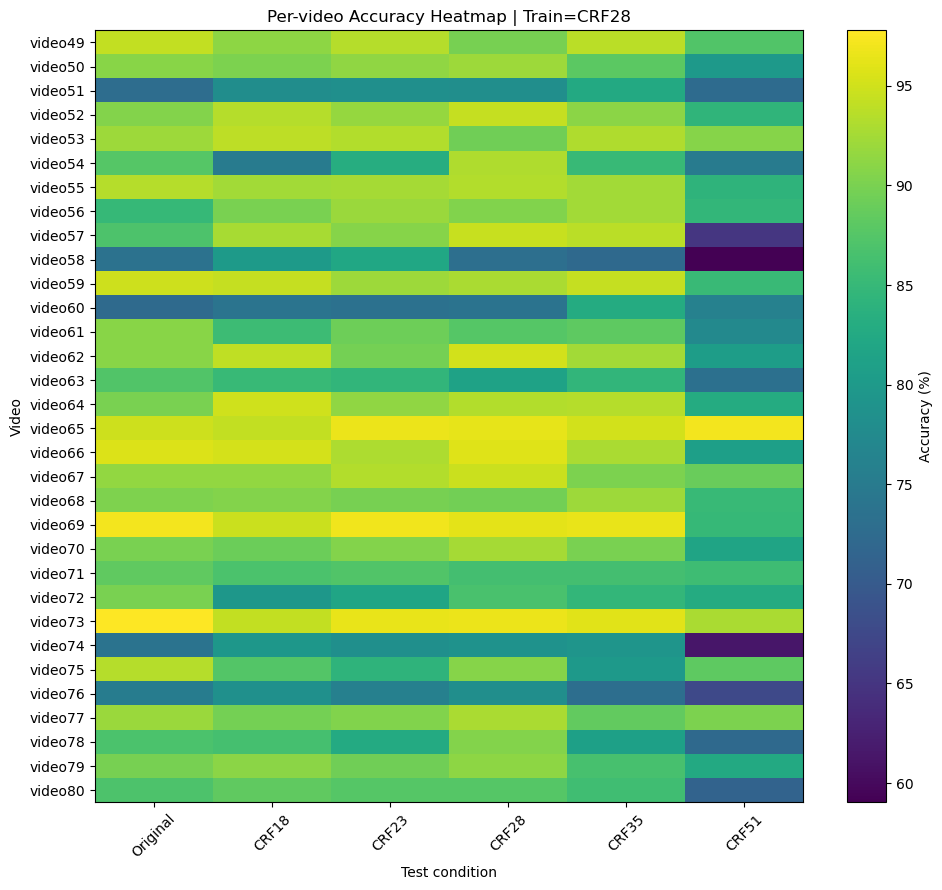

Saved: /export/fs06/ahallur1/cholec80/result_exports/per_video_heatmap_train_CRF35.png


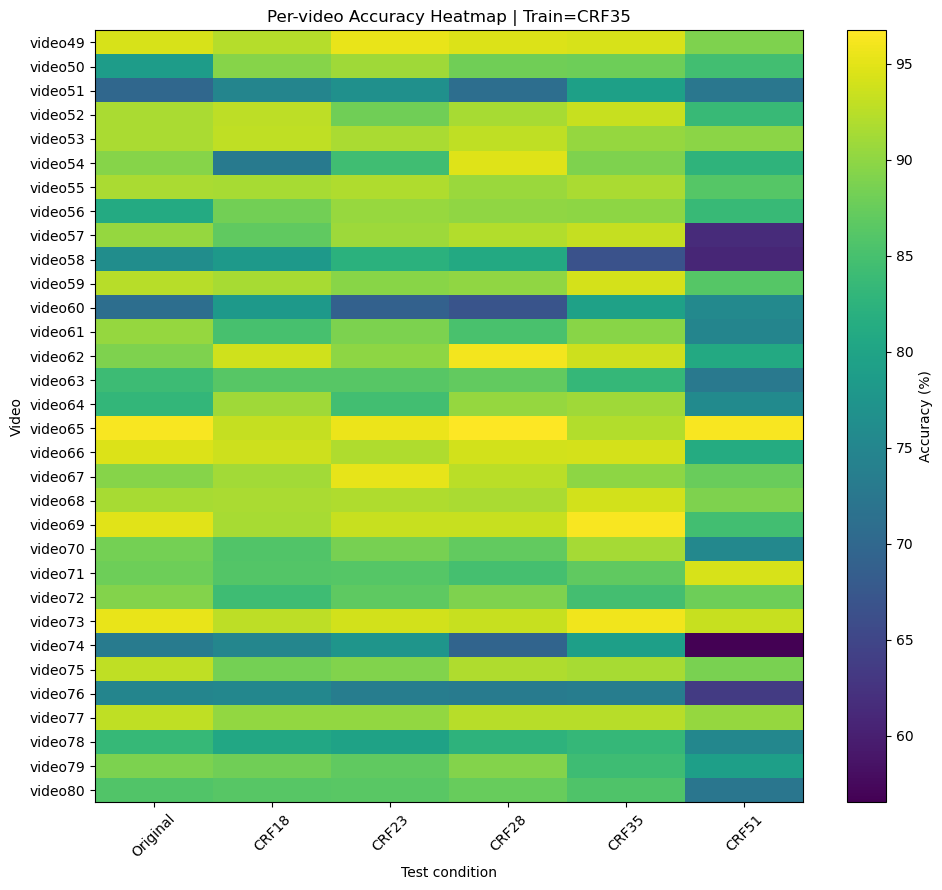

Saved: /export/fs06/ahallur1/cholec80/result_exports/per_video_heatmap_train_CRF51.png


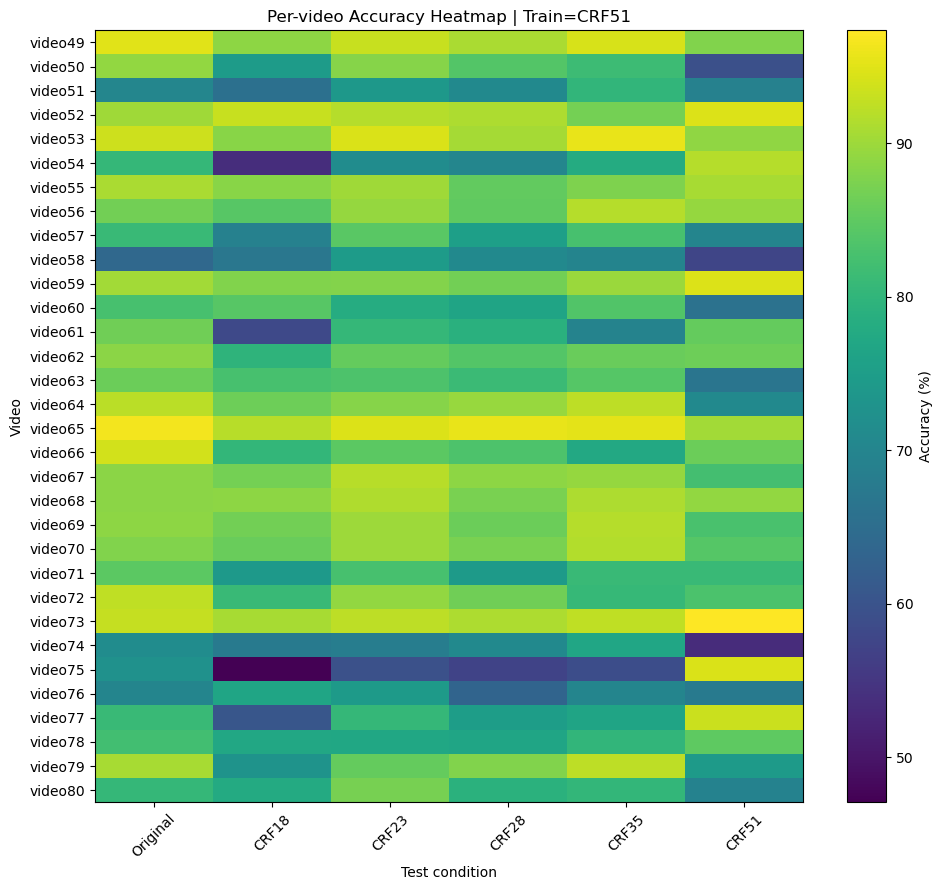

In [19]:
for train_cond in CONDITIONS:
    subset = pair_video_df[pair_video_df["train_condition"] == train_cond]
    if subset.empty:
        continue
    pivot = subset.pivot_table(index="video", columns="test_condition", values="accuracy").reindex(columns=CONDITIONS)
    plt.figure(figsize=(10, 9))
    im = plt.imshow(pivot.values * 100, aspect="auto")
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.colorbar(im, label="Accuracy (%)")
    plt.title(f"Per-video Accuracy Heatmap | Train={train_cond}")
    plt.xlabel("Test condition")
    plt.ylabel("Video")
    plt.tight_layout()
    save_fig(f"per_video_heatmap_train_{train_cond}.png")
    plt.show()

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_Original_test_Original.png


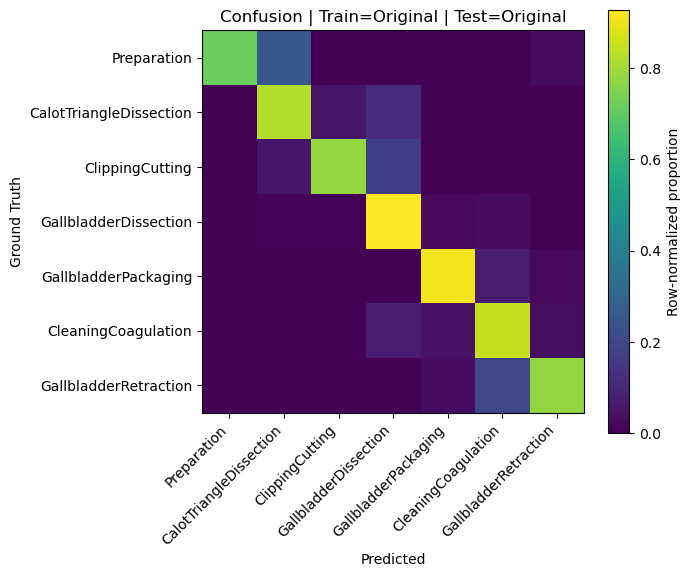

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_Original_test_CRF18.png


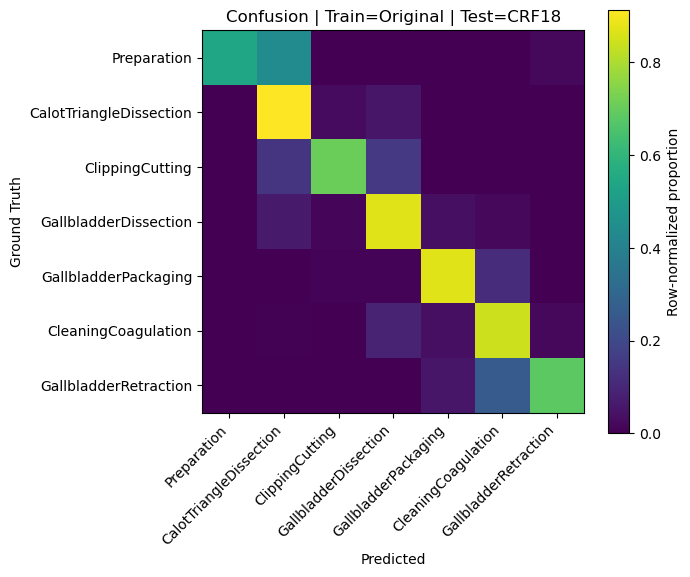

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_Original_test_CRF23.png


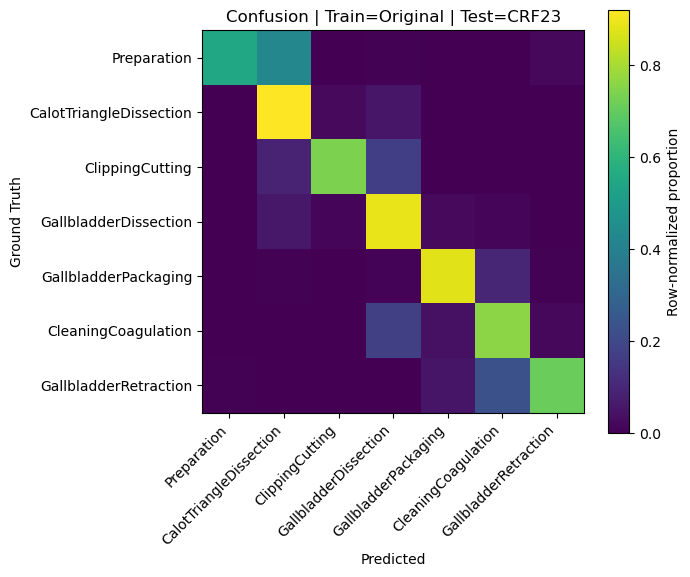

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_Original_test_CRF28.png


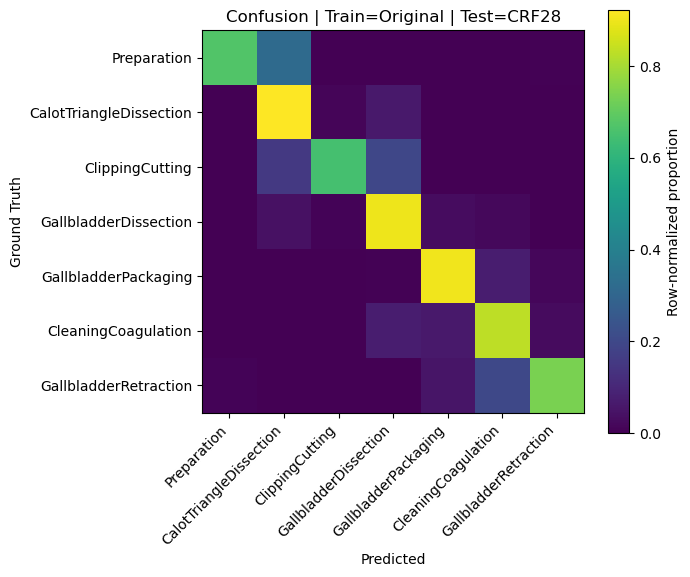

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_Original_test_CRF35.png


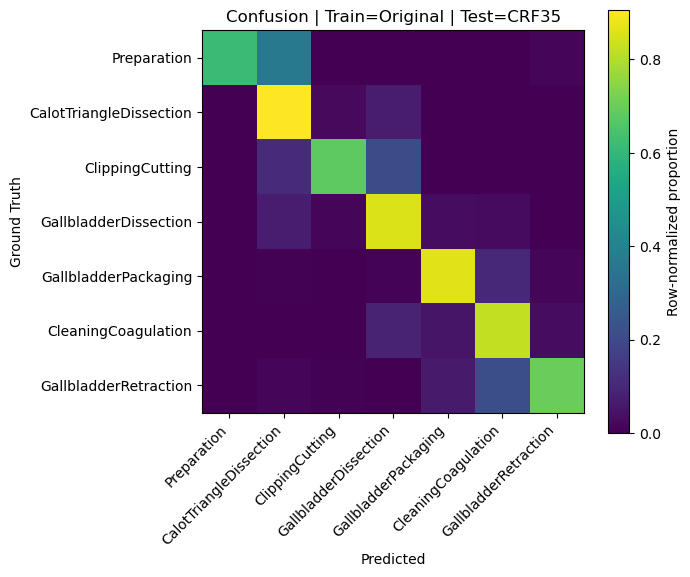

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_Original_test_CRF51.png


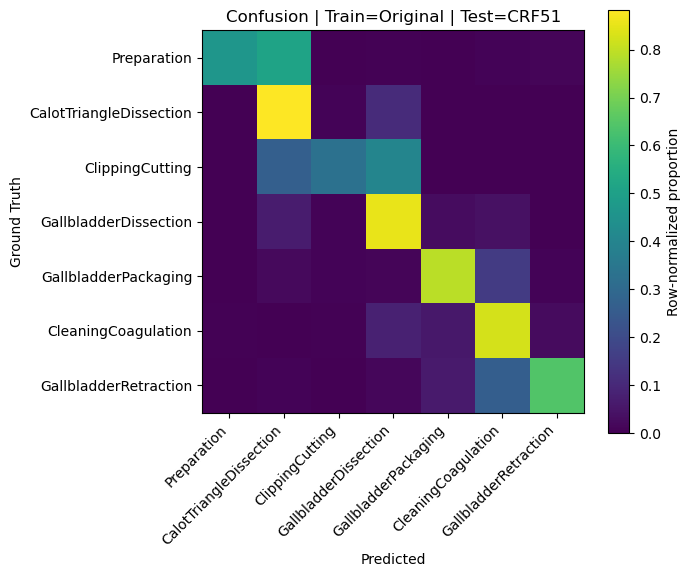

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF18_test_Original.png


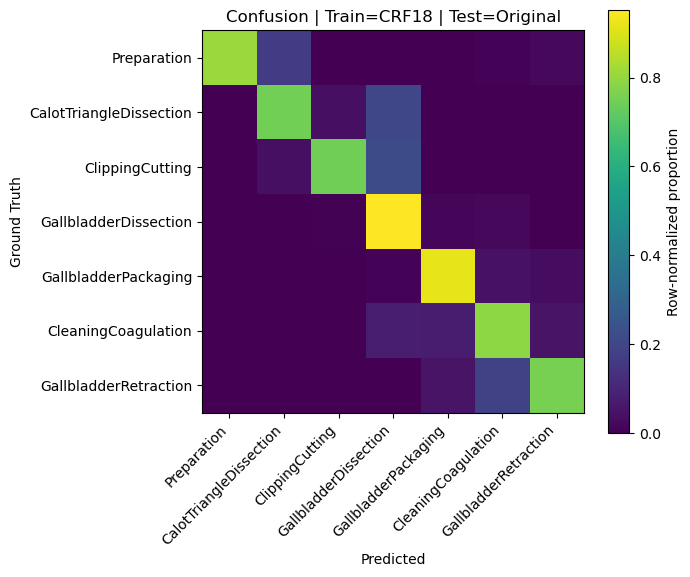

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF18_test_CRF18.png


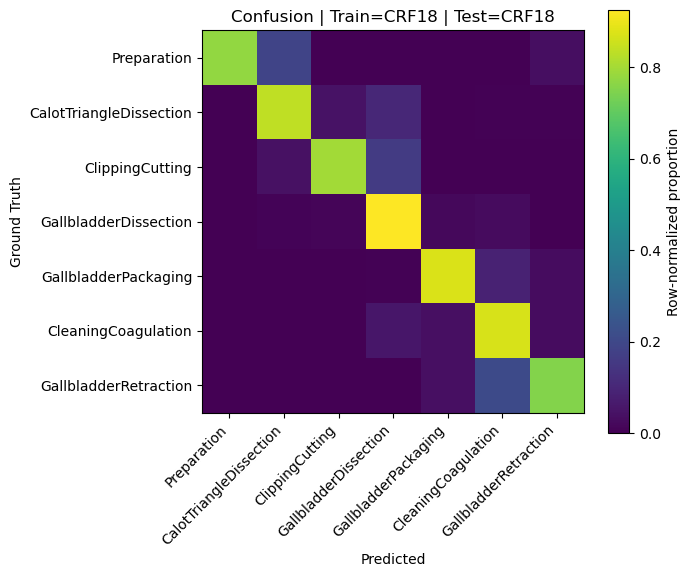

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF18_test_CRF23.png


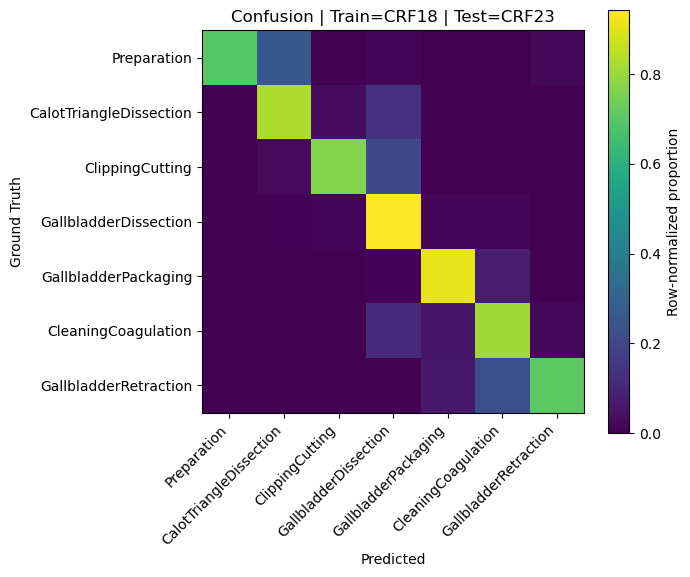

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF18_test_CRF28.png


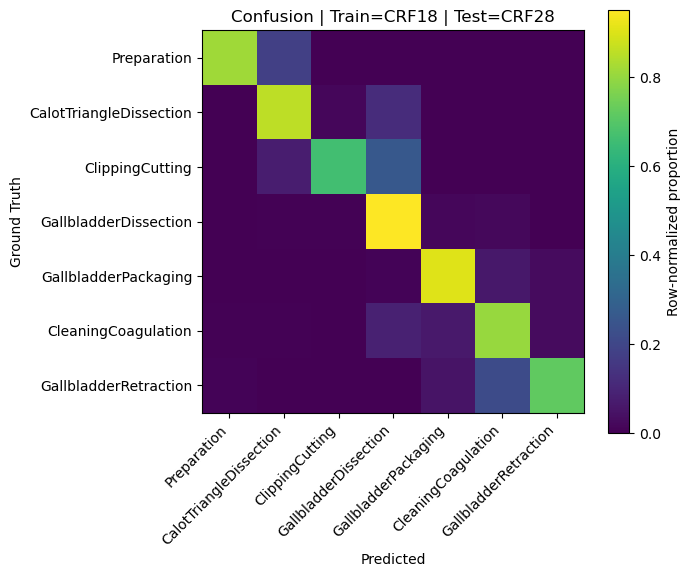

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF18_test_CRF35.png


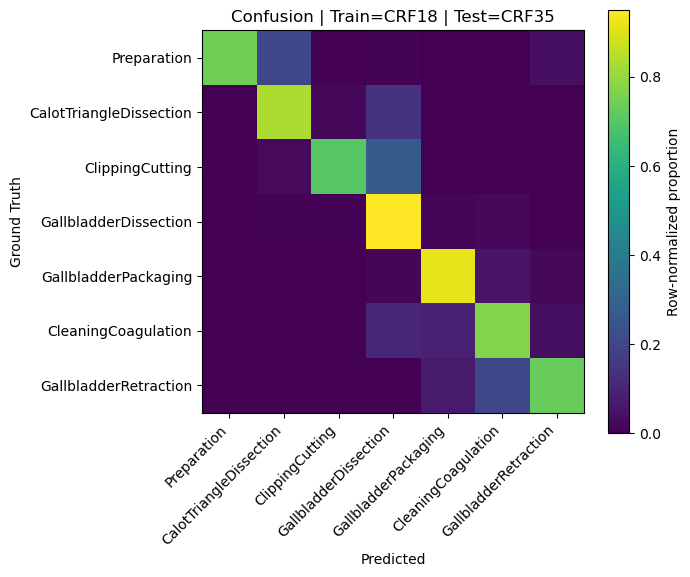

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF18_test_CRF51.png


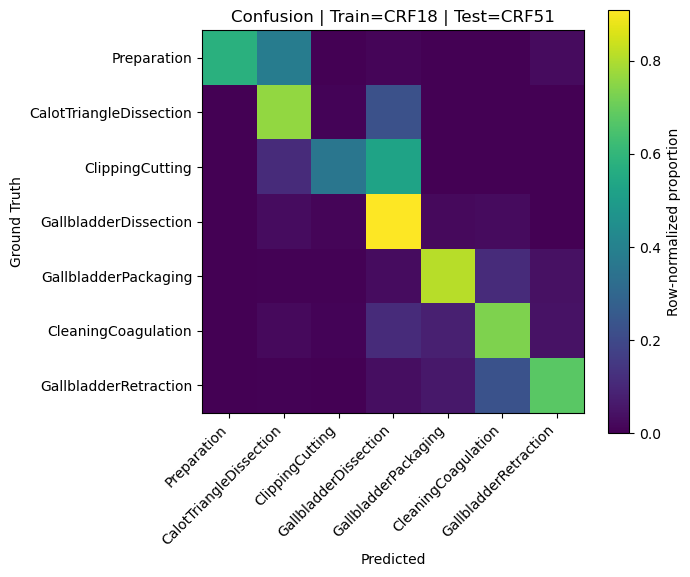

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF23_test_Original.png


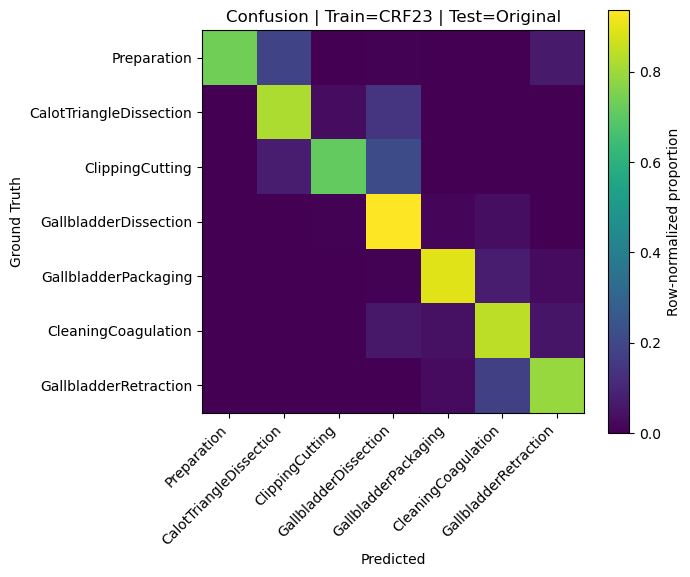

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF23_test_CRF18.png


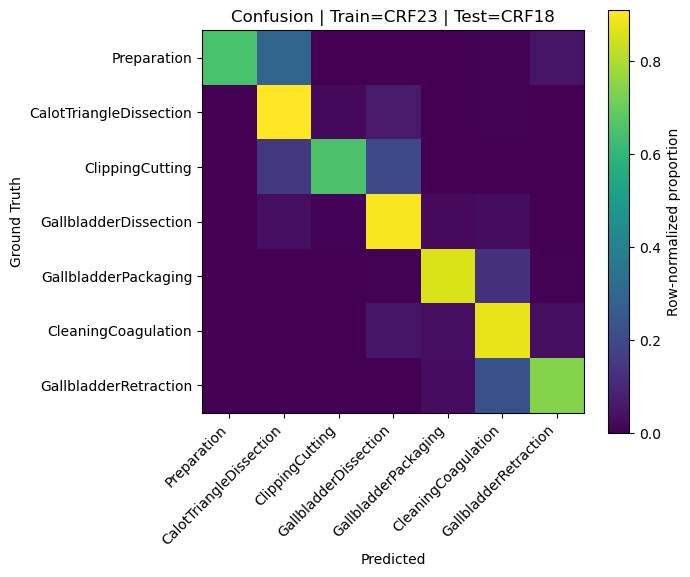

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF23_test_CRF23.png


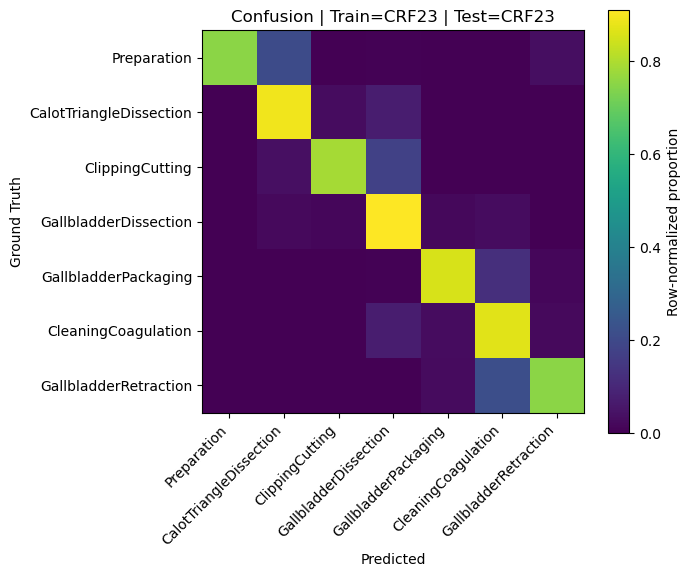

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF23_test_CRF28.png


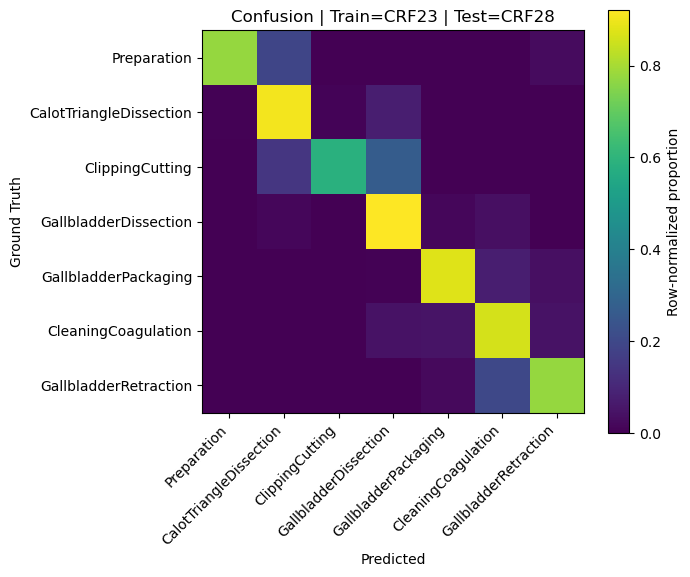

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF23_test_CRF35.png


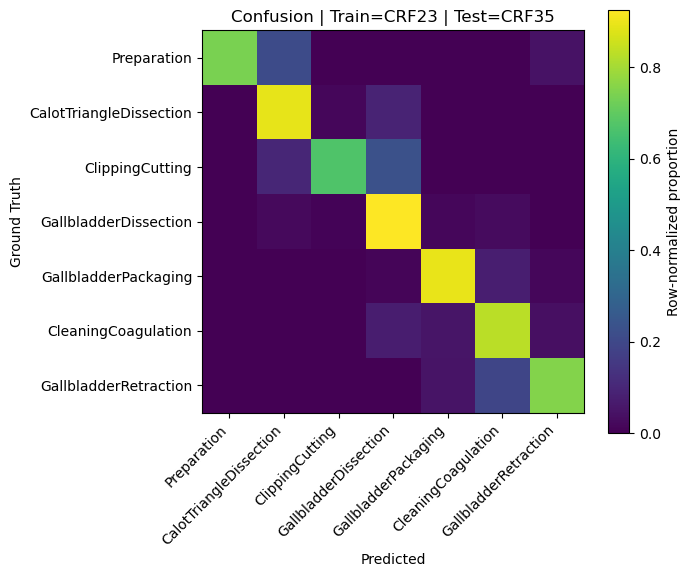

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF23_test_CRF51.png


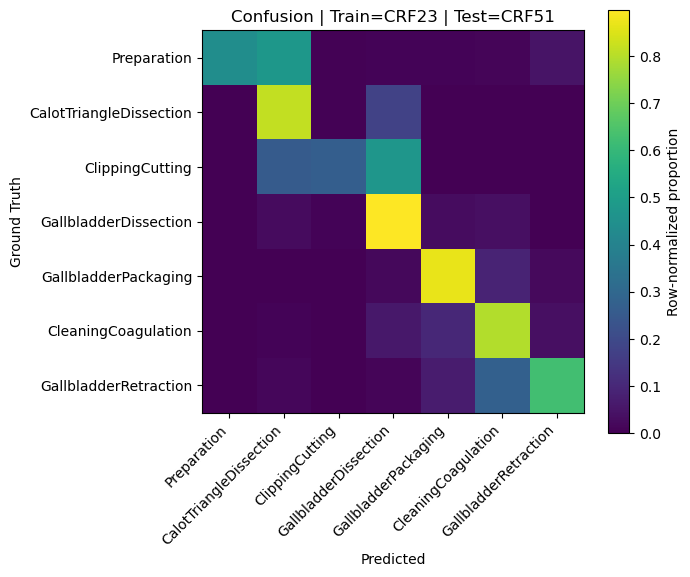

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF28_test_Original.png


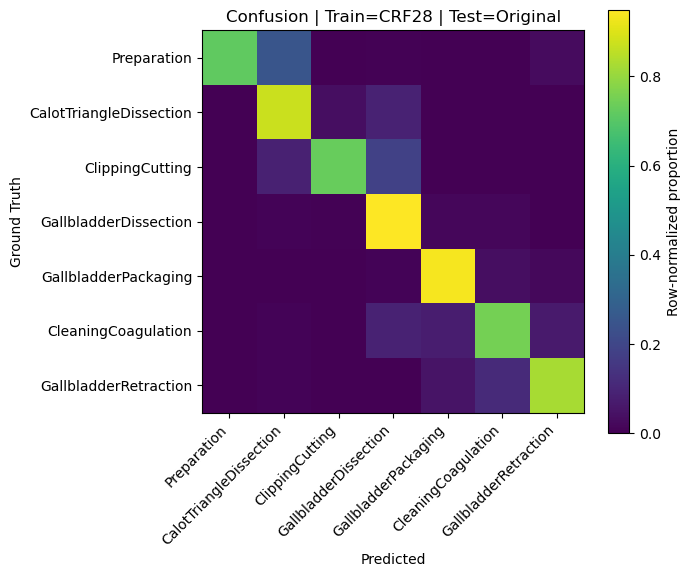

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF28_test_CRF18.png


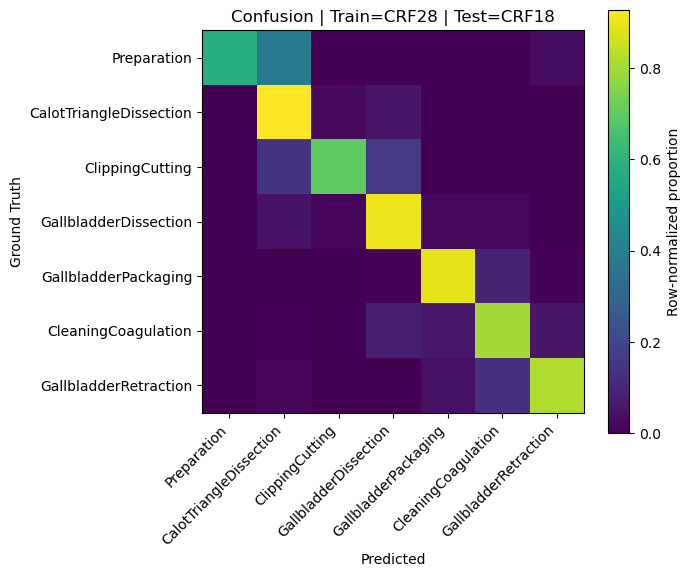

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF28_test_CRF23.png


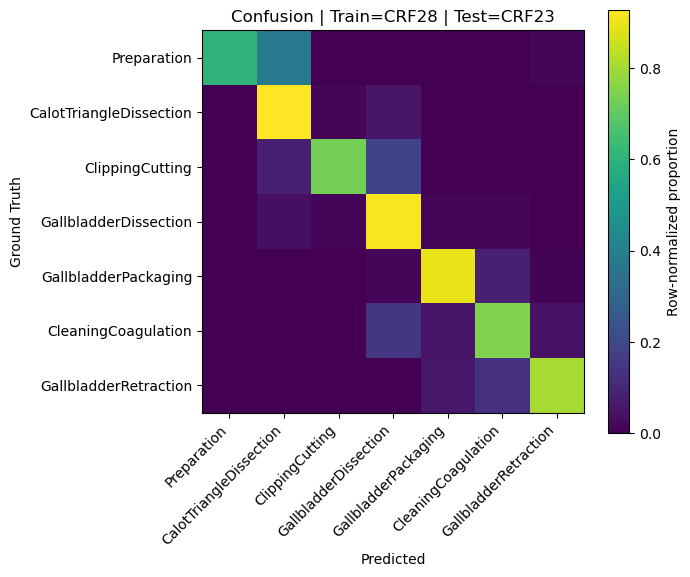

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF28_test_CRF28.png


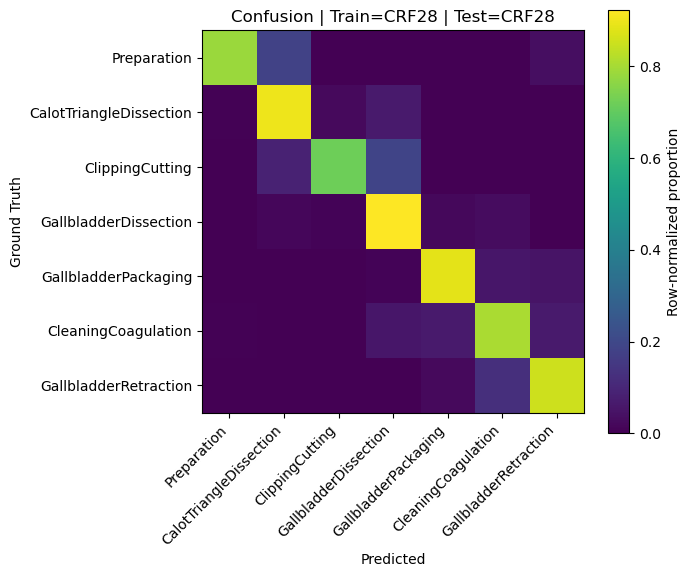

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF28_test_CRF35.png


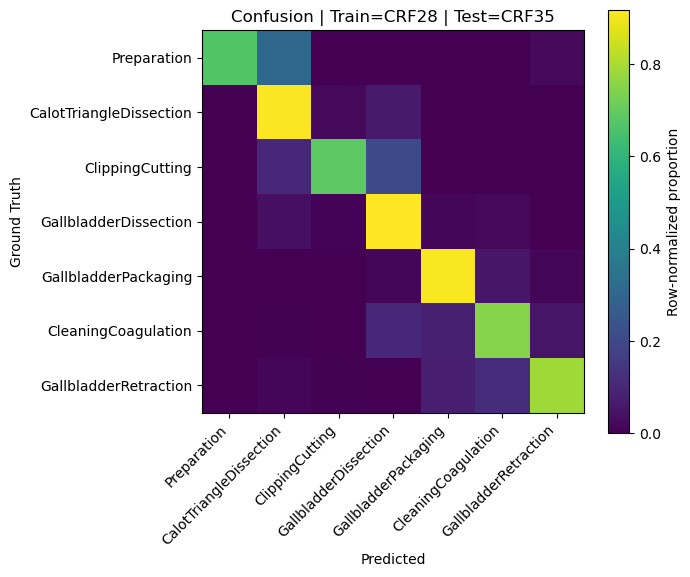

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF28_test_CRF51.png


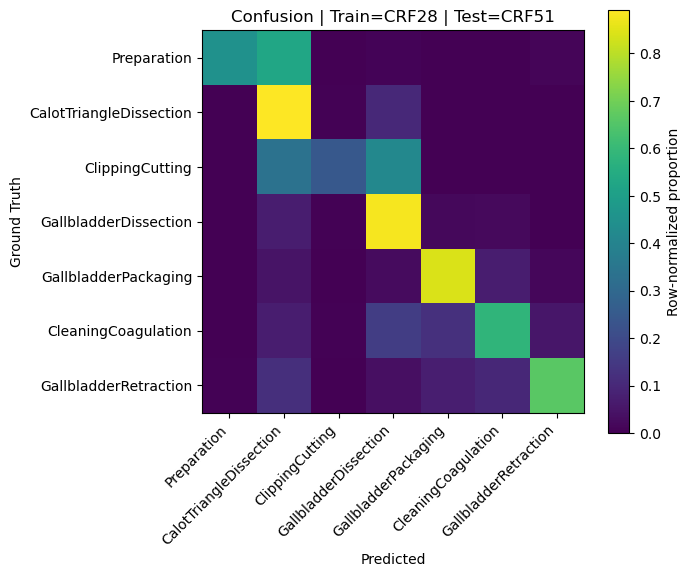

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF35_test_Original.png


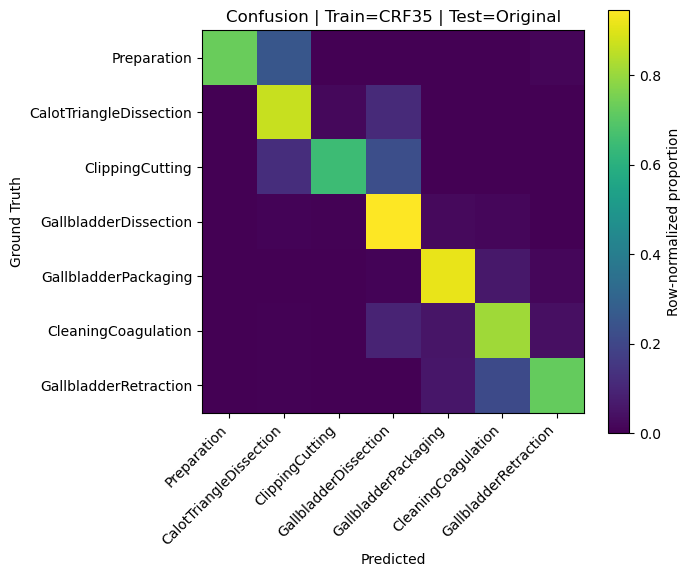

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF35_test_CRF18.png


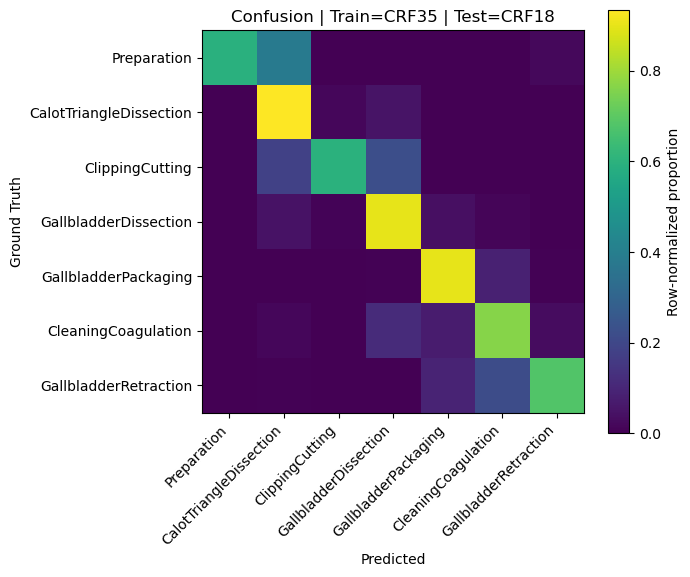

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF35_test_CRF23.png


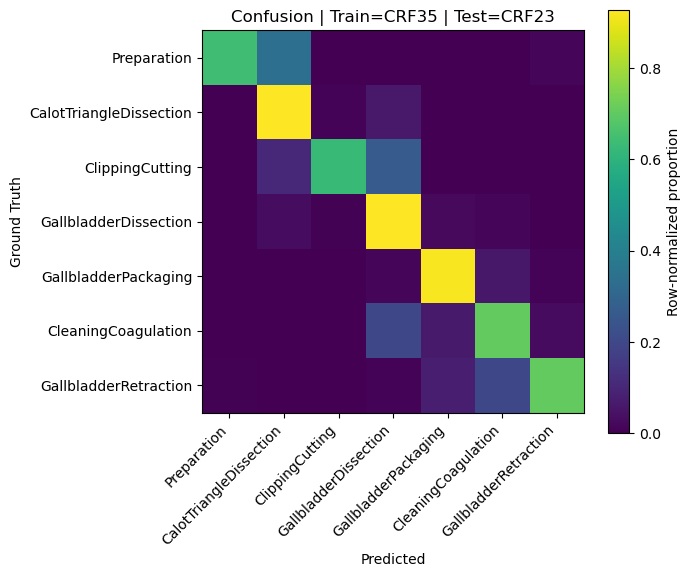

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF35_test_CRF28.png


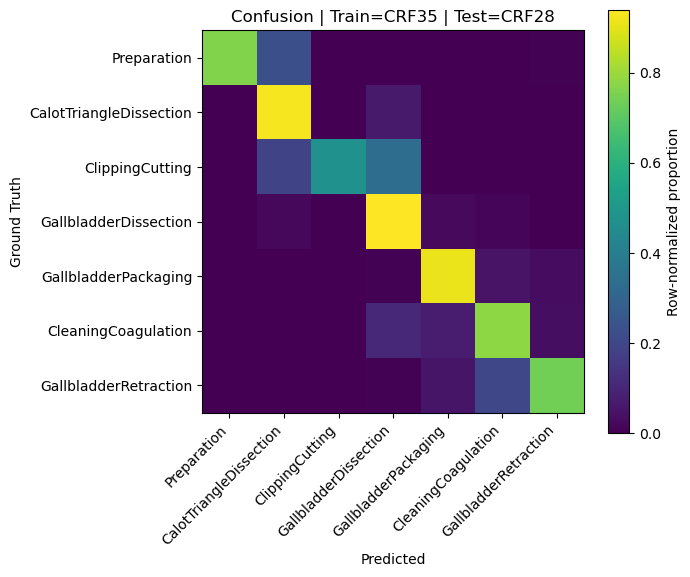

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF35_test_CRF35.png


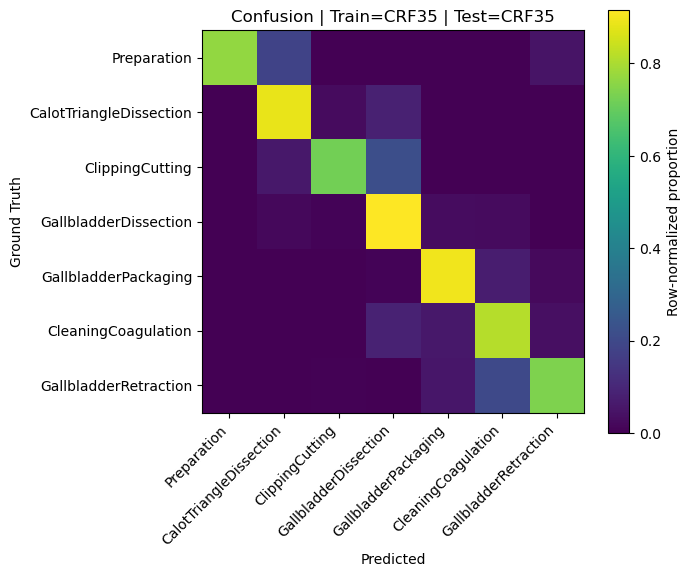

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF35_test_CRF51.png


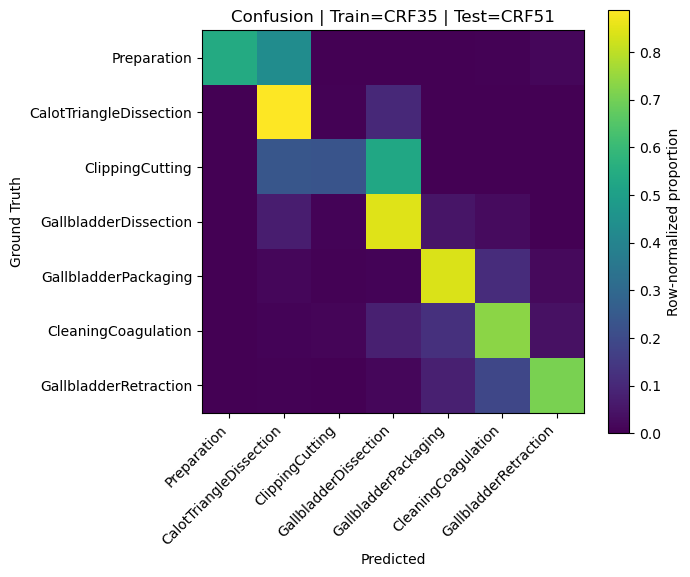

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF51_test_Original.png


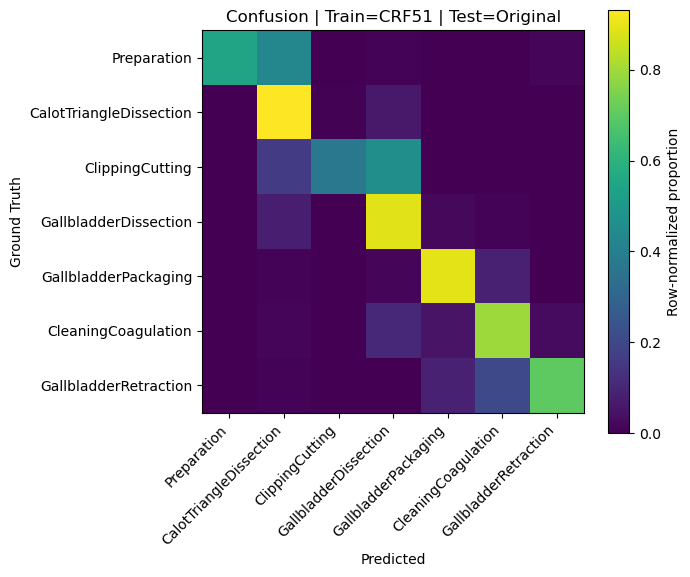

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF51_test_CRF18.png


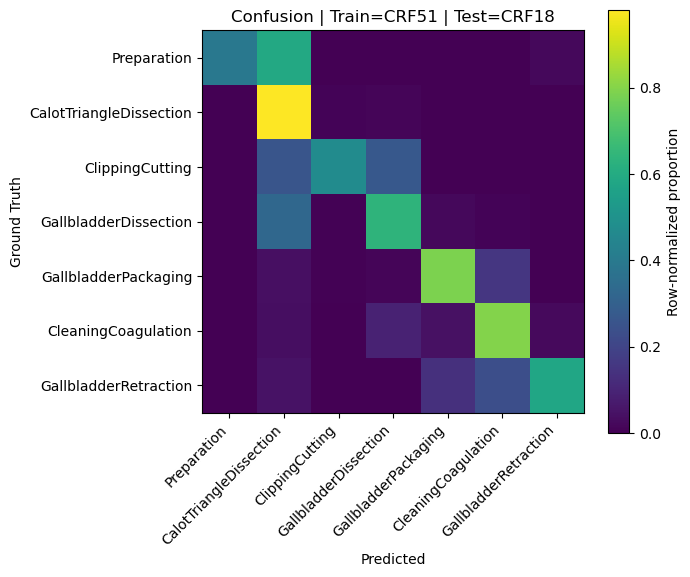

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF51_test_CRF23.png


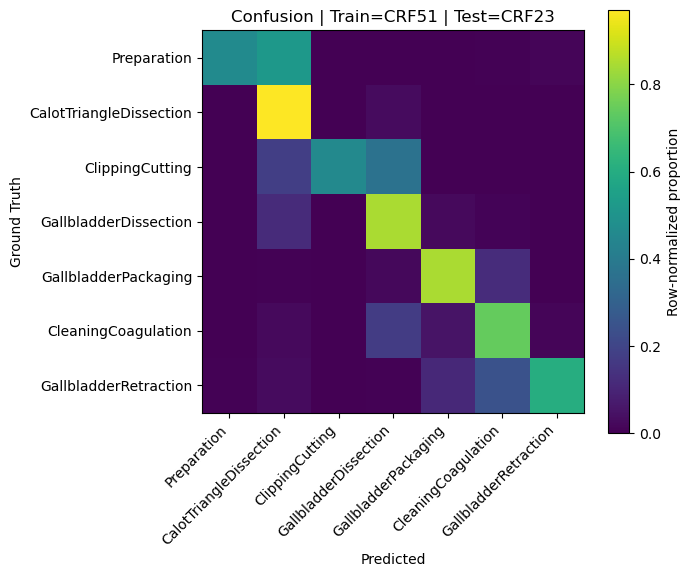

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF51_test_CRF28.png


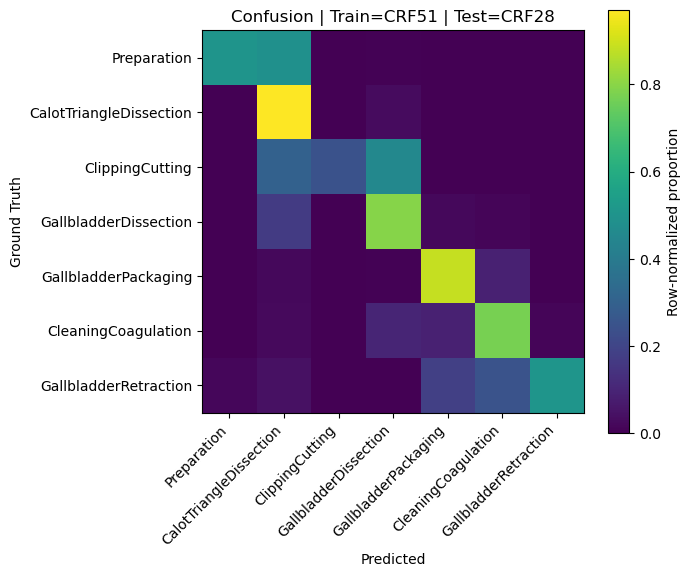

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF51_test_CRF35.png


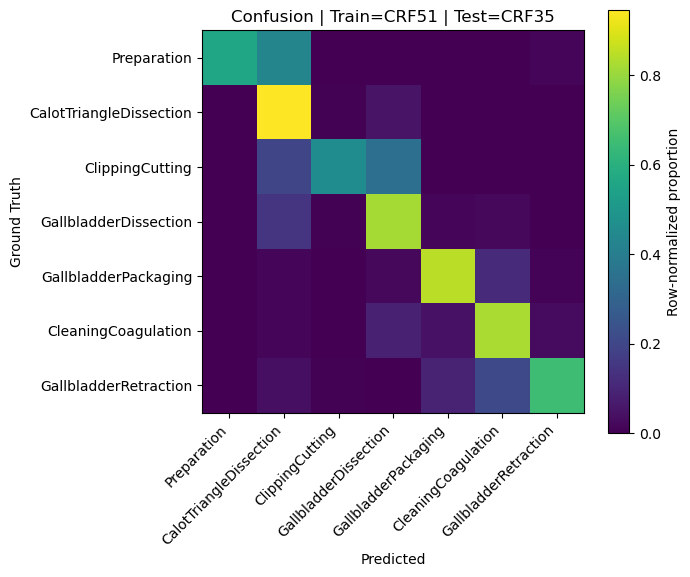

Saved: /export/fs06/ahallur1/cholec80/result_exports/confusion_train_CRF51_test_CRF51.png


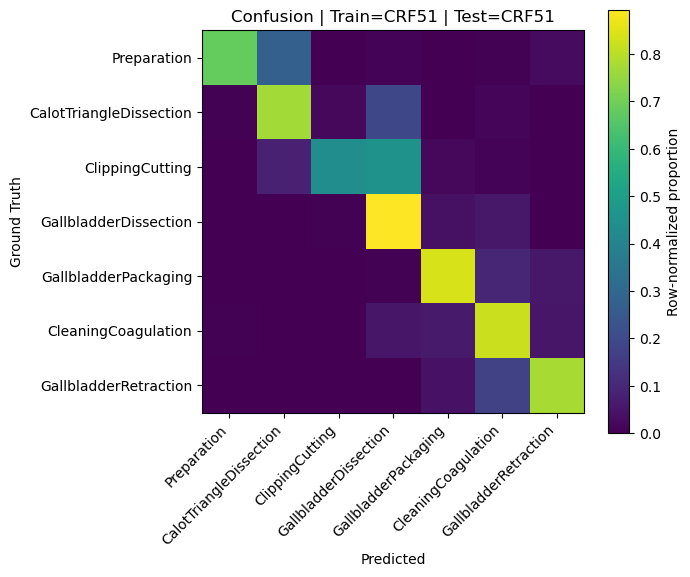

In [20]:
for train_cond in CONDITIONS:
    for test_cond in CONDITIONS:
        key = (train_cond, test_cond)
        if key not in pair_store:
            continue
        cm = np.asarray(pair_store[key]["cm"], dtype=float)
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_norm = np.divide(cm, row_sums, where=row_sums != 0)

        plt.figure(figsize=(7, 6))
        im = plt.imshow(cm_norm)
        plt.xticks(range(len(PHASES)), PHASES, rotation=45, ha="right")
        plt.yticks(range(len(PHASES)), PHASES)
        plt.colorbar(im, label="Row-normalized proportion")
        plt.title(f"Confusion | Train={train_cond} | Test={test_cond}")
        plt.xlabel("Predicted")
        plt.ylabel("Ground Truth")
        plt.tight_layout()
        save_fig(f"confusion_train_{train_cond}_test_{test_cond}.png")
        plt.show()

Saved: /export/fs06/ahallur1/cholec80/result_exports/ribbon_train_compare_Original_video58.png


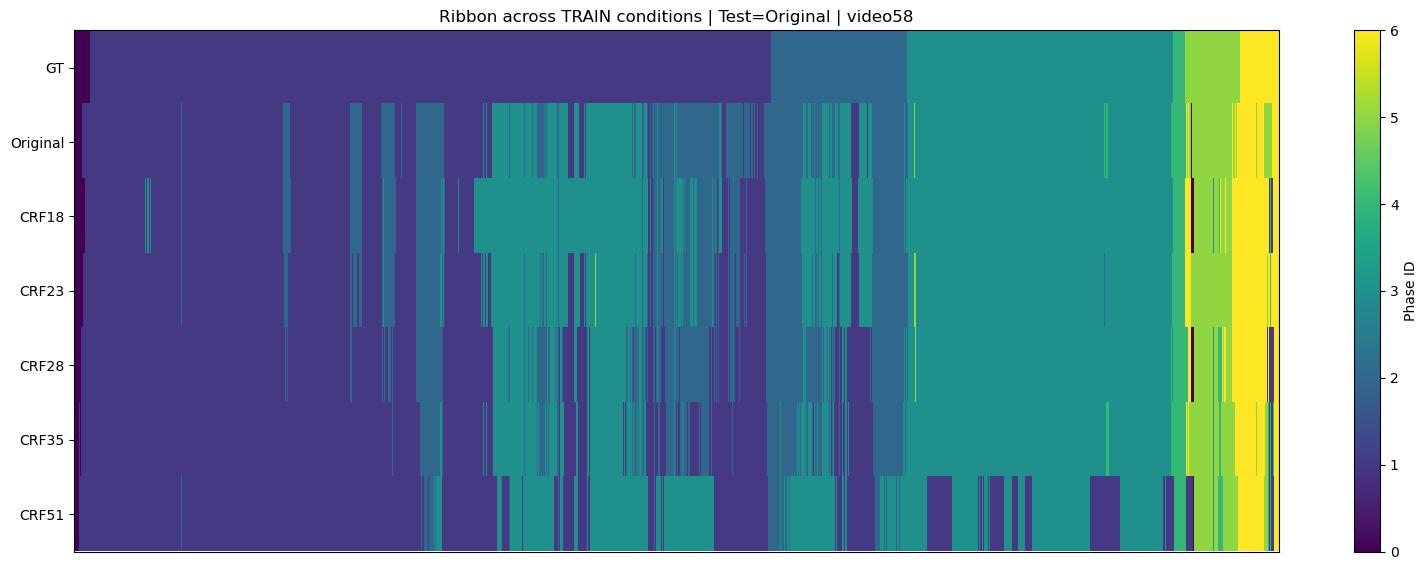

Saved: /export/fs06/ahallur1/cholec80/result_exports/ribbon_test_compare_Original_video58.png


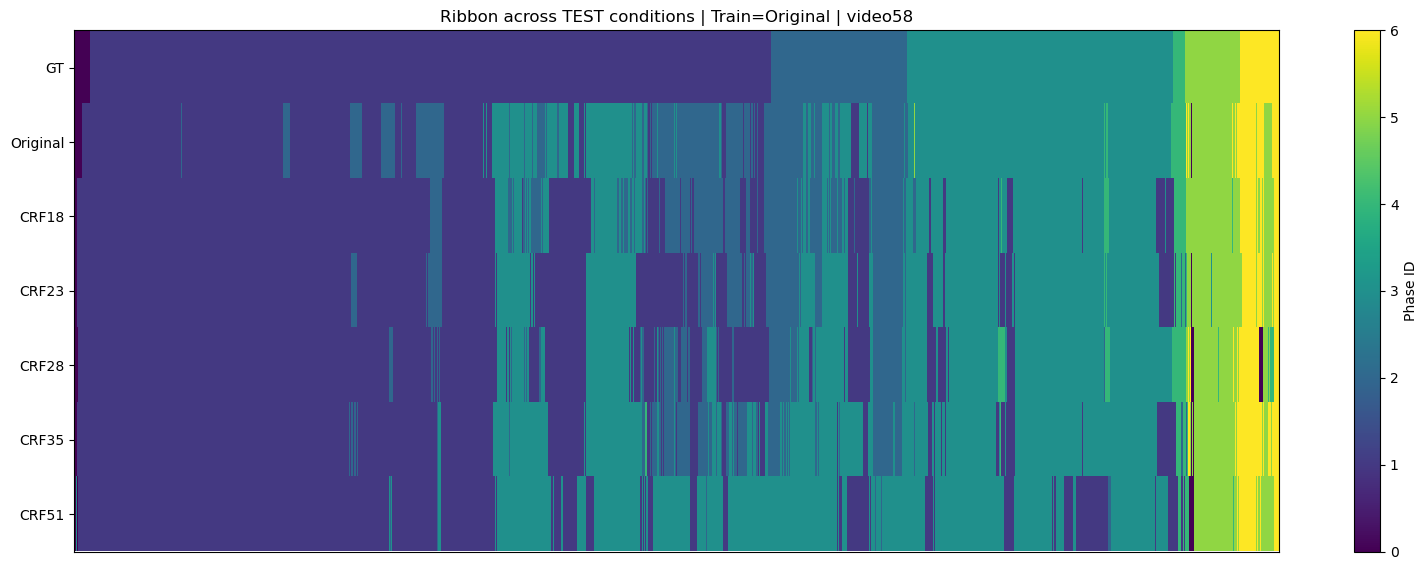

In [21]:
def ribbon_compare_train(video_name, test_cond):
    gt = read_gt_1fps(GT_DIR / f"{video_name}-phase.txt")
    rows = [gt]
    labels = ["GT"]
    for train_cond in CONDITIONS:
        key = (train_cond, test_cond)
        if key not in pair_store:
            continue
        pred_dir = pair_store[key]["pred_dir"]
        pred = read_pred_txt(pred_dir / f"{video_name}-phase.txt")
        usable = min(len(gt), len(pred))
        rows.append(pred[:usable])
        labels.append(train_cond)
    min_len = min(len(r) for r in rows)
    mat = np.vstack([r[:min_len] for r in rows])

    plt.figure(figsize=(16, 3 + 0.4 * len(rows)))
    im = plt.imshow(mat, aspect="auto", interpolation="nearest")
    plt.yticks(range(len(labels)), labels)
    plt.xticks([])
    plt.colorbar(im, ticks=range(7), label="Phase ID")
    plt.title(f"Ribbon across TRAIN conditions | Test={test_cond} | {video_name}")
    plt.tight_layout()
    save_fig(f"ribbon_train_compare_{test_cond}_{video_name}.png")
    plt.show()

def ribbon_compare_test(video_name, train_cond):
    gt = read_gt_1fps(GT_DIR / f"{video_name}-phase.txt")
    rows = [gt]
    labels = ["GT"]
    for test_cond in CONDITIONS:
        key = (train_cond, test_cond)
        if key not in pair_store:
            continue
        pred_dir = pair_store[key]["pred_dir"]
        pred = read_pred_txt(pred_dir / f"{video_name}-phase.txt")
        usable = min(len(gt), len(pred))
        rows.append(pred[:usable])
        labels.append(test_cond)
    min_len = min(len(r) for r in rows)
    mat = np.vstack([r[:min_len] for r in rows])

    plt.figure(figsize=(16, 3 + 0.4 * len(rows)))
    im = plt.imshow(mat, aspect="auto", interpolation="nearest")
    plt.yticks(range(len(labels)), labels)
    plt.xticks([])
    plt.colorbar(im, ticks=range(7), label="Phase ID")
    plt.title(f"Ribbon across TEST conditions | Train={train_cond} | {video_name}")
    plt.tight_layout()
    save_fig(f"ribbon_test_compare_{train_cond}_{video_name}.png")
    plt.show()

# Example plots
if ("Original", "Original") in pair_store:
    ribbon_compare_train("video58", "Original")
    ribbon_compare_test("video58", "Original")

In [22]:
pair_video_df.to_csv(RESULT_EXPORT_DIR / "cross_generalization_per_video_metrics.csv", index=False)
pair_summary_df.to_csv(RESULT_EXPORT_DIR / "cross_generalization_per_pair_summary.csv", index=False)
final_map_df.to_csv(RESULT_EXPORT_DIR / "cross_generalization_prediction_dir_map.csv", index=False)
phase_grid_df.to_csv(RESULT_EXPORT_DIR / "cross_generalization_per_phase_metrics.csv", index=False)
robustness_df.to_csv(RESULT_EXPORT_DIR / "cross_generalization_robustness_summary.csv", index=False)
diag_df.to_csv(RESULT_EXPORT_DIR / "cross_generalization_diag_vs_cross.csv", index=False)

print("Saved CSV files:")
for p in sorted(RESULT_EXPORT_DIR.glob("*.csv")):
    print(" ", p.name)

Saved CSV files:
  cross_generalization_diag_vs_cross.csv
  cross_generalization_per_pair_summary.csv
  cross_generalization_per_phase_metrics.csv
  cross_generalization_per_video_metrics.csv
  cross_generalization_prediction_dir_map.csv
  cross_generalization_robustness_summary.csv
